## 1. Load features and inspect per bearing

Data note: this copy of the 3rd test holds 6,324 files through 2004-04-18, while the IMS document (`docs/ims_bearing_readme.pdf`) describes 4,448 files ending 2004-04-04. The analysis uses the files on disk as found; the gap is stated, not hidden.

In [1]:
import src.config as config
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/3rd_test/'
print(f"Loading raw files from {DATA_DIR}...", flush=True)
df = extract_features(DATA_DIR)
print(f"Extraction done: {df.shape[0]} rows x {df.shape[1]} columns", flush=True)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

Loading raw files from data/raw/3rd_test/...
Extraction done: 6324 rows x 36 columns
=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std,Bearing_1_SpecCentroid,Bearing_1_HighFreqRatio,Bearing_1_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.079768,1.292720,7.133162,0.569,0.030877,0.079629,2900.483503,0.113801,0.063335
2004-03-04 09:32:46,0.078678,1.157037,6.240622,0.491,-0.013807,0.078512,3077.181630,0.144776,0.084005
2004-03-04 09:42:46,0.079815,0.890123,6.452419,0.515,0.033420,0.079784,3070.335416,0.138980,0.089831
2004-03-04 09:52:46,0.081082,1.181861,6.807885,0.552,-0.027040,0.081042,2996.691981,0.118711,0.059764
2004-03-04 10:02:46,0.079165,0.585798,4.812731,0.381,-0.017775,0.079124,3001.163020,0.126731,0.073100


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std,Bearing_2_SpecCentroid,Bearing_2_HighFreqRatio,Bearing_2_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.096720,0.776451,5.448737,0.527,0.152047,0.096641,3799.928740,0.326253,0.068290
2004-03-04 09:32:46,0.092008,0.701936,5.836461,0.537,0.146246,0.091866,3818.949318,0.333898,0.103519
2004-03-04 09:42:46,0.093430,0.936667,6.379091,0.596,0.171805,0.093403,3804.575379,0.338337,0.103559
2004-03-04 09:52:46,0.092803,0.379354,5.527828,0.513,0.166074,0.092796,3675.555137,0.319033,0.072276
2004-03-04 10:02:46,0.092829,0.504029,6.054119,0.562,0.145980,0.092826,3697.280415,0.324487,0.086263


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std,Bearing_3_SpecCentroid,Bearing_3_HighFreqRatio,Bearing_3_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.066390,0.592253,5.437565,0.361,0.083455,0.066190,3605.895118,0.327567,0.035414
2004-03-04 09:32:46,0.066285,0.360079,4.450449,0.295,0.011829,0.065984,3674.816798,0.344769,0.043557
2004-03-04 09:42:46,0.069186,0.214038,4.133782,0.286,0.049060,0.069174,3470.286314,0.319801,0.060433
2004-03-04 09:52:46,0.068637,0.299358,5.084751,0.349,0.002209,0.068599,3517.982942,0.318080,0.039290
2004-03-04 10:02:46,0.067469,0.396086,5.750781,0.388,0.031886,0.067447,3543.133855,0.329432,0.038203


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std,Bearing_4_SpecCentroid,Bearing_4_HighFreqRatio,Bearing_4_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.055493,0.560054,5.460190,0.303,0.038848,0.055323,3021.688928,0.103884,0.027727
2004-03-04 09:32:46,0.053351,0.356036,4.667234,0.249,0.013905,0.052925,2988.231816,0.121953,0.042174
2004-03-04 09:42:46,0.052703,0.478295,5.274828,0.278,0.034238,0.052606,3002.865429,0.124729,0.047238
2004-03-04 09:52:46,0.054844,0.342058,5.470035,0.300,0.007404,0.054669,2990.955046,0.123240,0.031650
2004-03-04 10:02:46,0.053914,0.261778,4.581358,0.247,0.023475,0.053804,2931.272902,0.123450,0.037605


## 2. All features over the full timeline

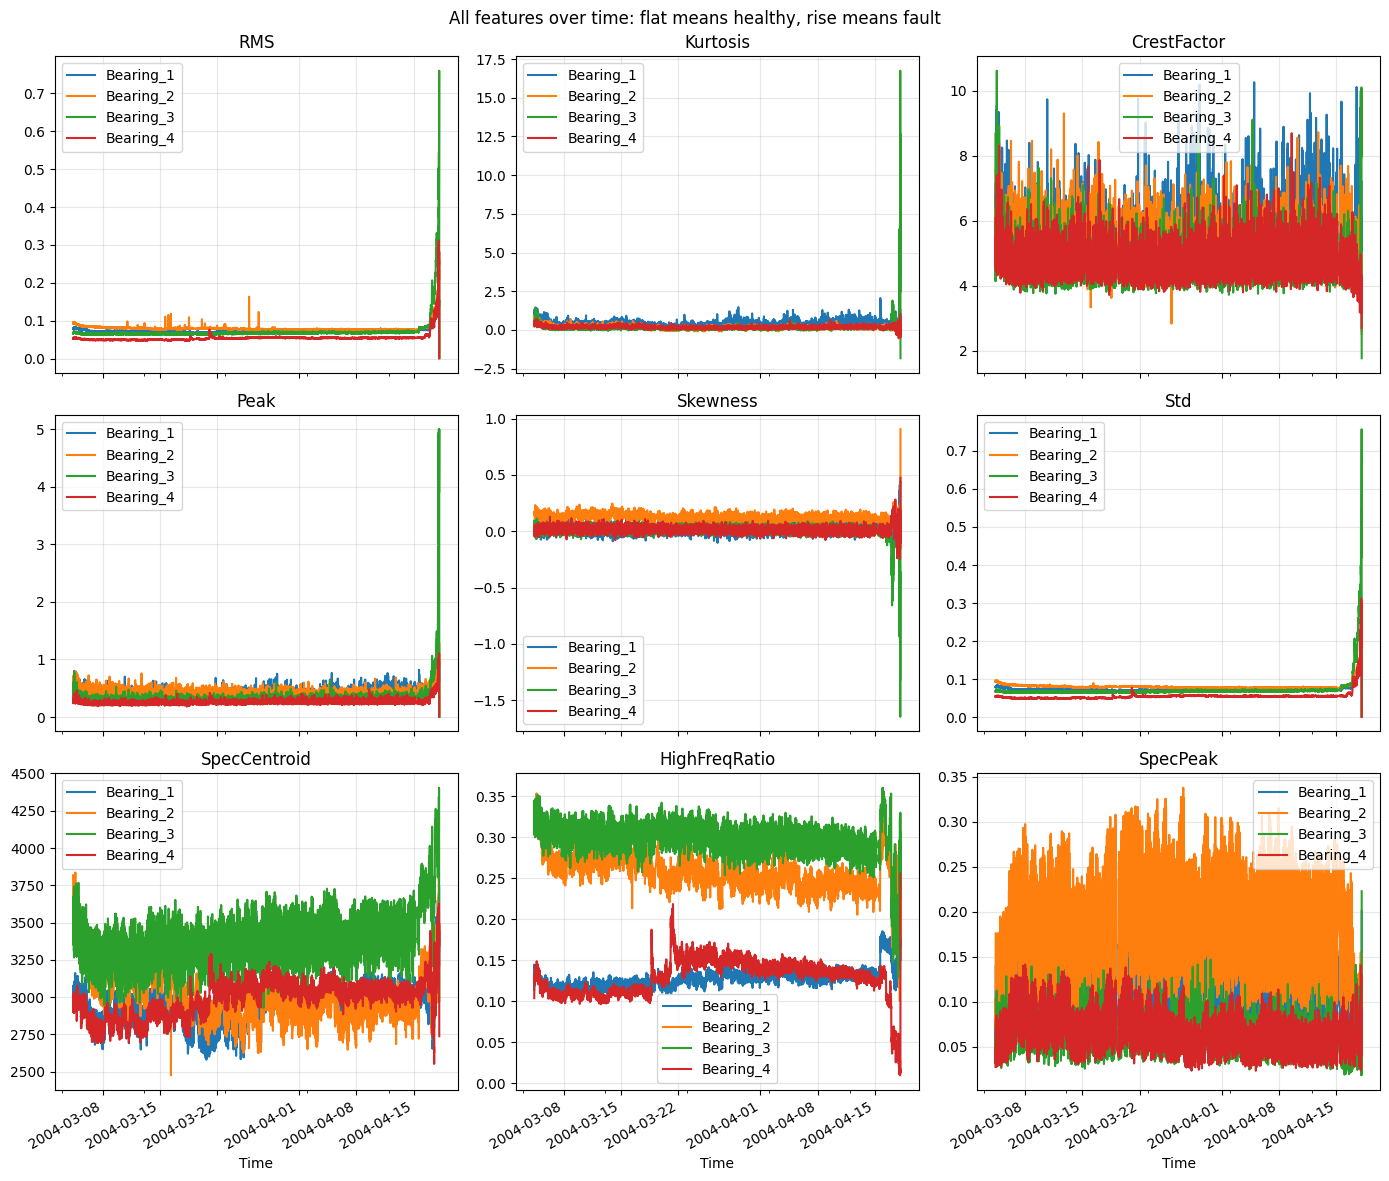

In [2]:
features = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
            'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True)
for ax, feat in zip(axes.flat, features):
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    renamed = {c: c.replace('_' + feat, '') for c in cols}
    df[cols].rename(columns=renamed).plot(ax=ax)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
plt.suptitle('All features over time: flat means healthy, rise means fault')
plt.tight_layout()
plt.show()

## 3. Fault localization: which bearing fails

### How the verdict is computed

The verdict is a vote, not a single number: for each bearing and each of RMS, Kurtosis, Peak and Std, growth = mean(last 100 files) / mean(first 100 files); the bearing with the highest average growth wins. Bearing_3 wins by a landslide (RMS 4.01, Peak 4.03, Kurtosis 2.98) against Bearing_4 (2.61), Bearing_2 (1.65) and Bearing_1 (1.43). CrestFactor is deliberately excluded from the vote: its growth ratios sit below 1 everywhere (0.76-0.92), i.e. the feature decreases late vs early, so it cannot witness growth - and since crest factor itself can never be below 1, a ratio below 1 must be read as a decrease, never as a value.

In [3]:
from src.evaluation import identify_faulty_bearing

result = identify_faulty_bearing(df)
display(result['summary'])
print(f"Faulty bearing: {result['faulty_bearing']}")

,rms_growth,kurtosis_growth,crest_factor_growth,peak_growth,std_growth
bearing,,,,,
Bearing_1,1.43,0.46,0.88,1.27,1.43
Bearing_2,1.65,0.03,0.76,1.25,1.66
Bearing_3,4.01,2.98,0.92,4.03,4.01
Bearing_4,2.61,0.22,0.77,1.97,2.62


Faulty bearing: Bearing_3


## 4. Faulty bearing in detail

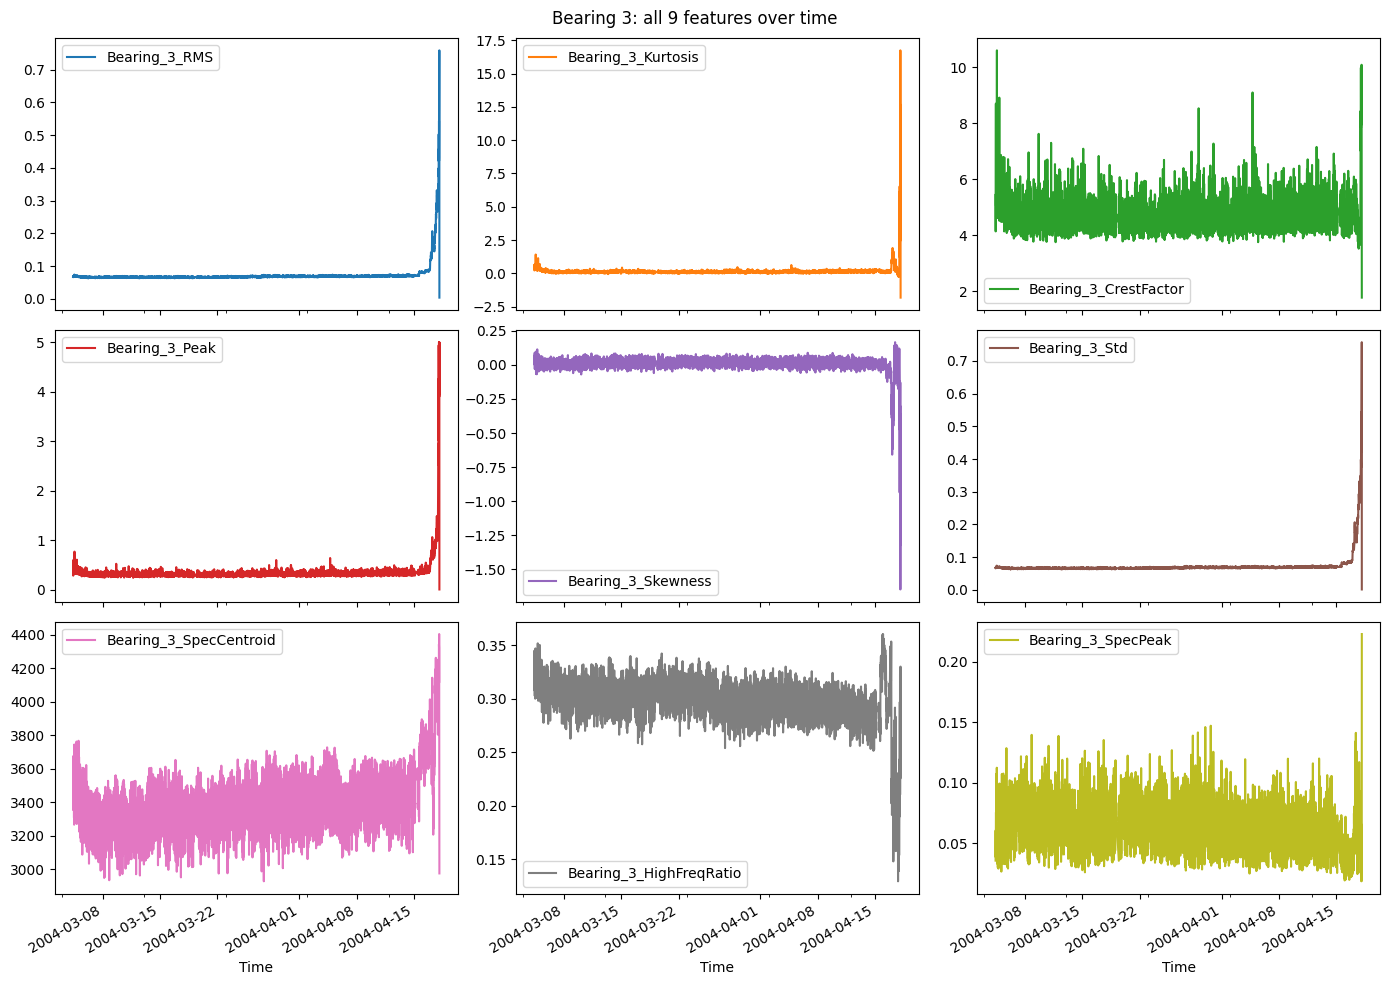

In [4]:
bearing3_cols = [c for c in df.columns if 'Bearing_3_' in c]
df[bearing3_cols].plot(figsize=(14, 10), subplots=True, layout=(3, 3))
plt.suptitle('Bearing 3: all 9 features over time')
plt.tight_layout()
plt.show()

## 5. Compare healthy boundary candidates

In [5]:
from src.evaluation import compare_boundaries

scores = df['Bearing_3_RMS']
candidates = [
    pd.Timestamp('2004-03-15'),
    pd.Timestamp('2004-03-18'),
    pd.Timestamp('2004-03-22'),
    pd.Timestamp('2004-03-25'),
    pd.Timestamp('2004-03-28'),
    pd.Timestamp('2004-03-31'),
    pd.Timestamp('2004-04-03'),
    pd.Timestamp('2004-04-06'),
    pd.Timestamp('2004-04-09'),
    pd.Timestamp('2004-04-12'),
    pd.Timestamp('2004-04-14'),
]
compare_boundaries(scores, candidates)

# Same vote over n_std x window grid, side by side in this section
from src.evaluation import sweep_boundary_params
bnd_sweep = sweep_boundary_params(scores, candidates, n_stds=(2.0, 3.0), windows=(10, 15, 20))
print("Boundary x rule x window - first alarm:")
display(bnd_sweep.pivot_table(index=['rule', 'window'], columns='boundary', values='first_alarm', aggfunc='first', observed=False))
print("Boundary x rule x window - FPR:")
display(bnd_sweep.pivot_table(index=['rule', 'window'], columns='boundary', values='fpr', aggfunc='first', observed=False).style.format('{:.4f}'))

Boundary x rule x window - first alarm:


boundary                    2004-03-15          2004-03-18  \
rule        window                                           
mean+2.0std 10     2004-03-04 13:52:46 2004-03-04 13:52:46   
            15     2004-04-12 04:01:57 2004-04-11 21:21:57   
            20     2004-04-12 09:01:57 2004-04-11 22:11:57   
mean+3.0std 10     2004-04-15 11:52:55 2004-04-15 11:52:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   
pct_99.5    10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   

boundary                    2004-03-22          2004-03-25  \
rule        window                                           
mean+2.0std 10     2004-03-04 13:52:46 2004-03-04 13:52:46   
            15     2004-04-10 14:31:57 2004-04-11 21:21:57   
            20     2004-04-11 09:11:57 2004-04-11 22:11:57   
mean+3.0std 10     2004-04-12 07:31:57 2004-04-15 11:52:55   
            15     2004-04-15 12:42:55 2004-04-15 12:42:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   
pct_99.5    10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   

boundary                    2004-03-28          2004-03-31  \
rule        window                                           
mean+2.0std 10     2004-03-04 13:52:46 2004-04-12 03:31:57   
            15     2004-04-12 04:01:57 2004-04-15 10:52:55   
            20     2004-04-12 09:01:57 2004-04-15 11:42:55   
mean+3.0std 10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   
pct_99.5    10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   

boundary                    2004-04-03          2004-04-06  \
rule        window                                           
mean+2.0std 10     2004-04-12 07:31:57 2004-04-15 11:52:55   
            15     2004-04-15 12:42:55 2004-04-15 17:32:55   
            20     2004-04-15 13:32:55 2004-04-15 18:22:55   
mean+3.0std 10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   
pct_99.5    10     2004-04-15 16:42:55 2004-04-15 16:42:55   
            15     2004-04-15 17:32:55 2004-04-15 17:32:55   
            20     2004-04-15 18:22:55 2004-04-15 18:22:55   

boundary                    2004-04-09          2004-04-12          2004-04-14  
rule        window                                                              
mean+2.0std 10     2004-04-15 11:52:55 2004-04-15 16:42:55 2004-04-15 16:42:55  
            15     2004-04-15 17:32:55 2004-04-15 17:32:55 2004-04-15 17:32:55  
            20     2004-04-15 18:22:55 2004-04-15 18:22:55 2004-04-15 18:22:55  
mean+3.0std 10     2004-04-15 16:42:55 2004-04-15 16:42:55 2004-04-15 16:52:55  
            15     2004-04-15 17:32:55 2004-04-15 17:32:55 2004-04-15 17:42:55  
            20     2004-04-15 18:22:55 2004-04-15 18:22:55 2004-04-15 18:32:55  
pct_99.5    10     2004-04-15 16:42:55 2004-04-15 16:42:55 2004-04-15 16:42:55  
            15     2004-04-15 17:32:55 2004-04-15 17:32:55 2004-04-15 17:32:55  
            20     2004-04-15 18:22:55 2004-04-15 18:22:55 2004-04-15 18:22:55

Boundary x rule x window - FPR:


### Reading the table above

The vote is deliberately one-dimensional (Bearing_3 RMS only): the question here is *where* healthy ends, not *what* detects best - that comes in sections 8-9. Three findings:

- **The fault signal is boundary-independent.** Under mean+3std and percentile, every boundary from 03-28 onward alarms on the fault day 15.04 (w10: 16:42:55, w15: 17:32:55, w20: 18:22:55), and even the earliest boundaries do. The 15.04 jump is so strong that whatever healthy set trains the threshold, the detector still lands on the same day. Only the loose rule (mean+2std) with the short window (w10) gets distracted by the 04.03 startup for early boundaries.
- **12.04 is the last safe boundary.** 14.04 costs ~10 minutes (w10/mean+3std slips 16:42:55 -> 16:52:55) and risks swallowing early degradation: RMS already creeps to 0.069-0.073 on 13-14.04 against a healthy 0.0675. At 12.04 the validation FPR under mean+3std is 0.0013 - the threshold is calm and the fault day untouched.
- **The boundary does not depend on the window.** 12.04 gives fault-day alarms under w10, w15 and w20 alike (only the hour shifts). That is also the fairness proof for running the detectors at w10/w15 while the vote display defaults to w20: the two windows answer different questions (persistence for *where*, earliness for *when*), and the sweep shows no window was cherry-picked to justify the boundary.


## 6. Decision: chosen healthy boundary

Limitation (stated, not hidden): the boundary vote in section 5 uses RMS over the full timeline, so the 12.04 choice is made with hindsight - a deployed system would not know the future. Detectors therefore alarm "like RMS" partly by construction here; the transfer check against the 2nd test and the boundary-stability sweep are the guards, not a cure.

In [6]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-04-12')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-04-12 00:00:00


## 7. Split into healthy / full dataset

In [7]:
from src.preprocessing import split_healthy, scale_features, split_train_val

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
df_healthy_train, df_healthy_val = split_train_val(df_healthy, val_fraction=0.2)

print(f"Healthy total: {len(df_healthy)}")
print(f"Healthy train: {len(df_healthy_train)} ({df_healthy_train.index[0]} to {df_healthy_train.index[-1]})")
print(f"Healthy val:   {len(df_healthy_val)} ({df_healthy_val.index[0]} to {df_healthy_val.index[-1]})")

X_healthy_train, X_all, scaler = scale_features(df_healthy_train, df)
X_healthy_val = scaler.transform(df_healthy_val)
input_dim = X_healthy_train.shape[1]
n_spectral = len([c for c in df.columns if 'Spec' in c or 'High' in c])
print(f"Feature dimension: {input_dim} ({input_dim - n_spectral} time + {n_spectral} spectral)")

Healthy total: 5485
Healthy train: 4388 (2004-03-04 09:27:46 to 2004-04-04 09:01:57)
Healthy val:   1097 (2004-04-04 09:11:57 to 2004-04-11 23:51:57)
Feature dimension: 36 (24 time + 12 spectral)


## 8. Classical models

In [8]:
from src.classical_models import (
    fit_isolation_forest, score_isolation_forest,
    fit_one_class_svm, score_one_class_svm,
    fit_lof, score_lof,
    fit_pca, score_pca,
)
classical = [
    ('IsolationForest', fit_isolation_forest, score_isolation_forest),
    ('OneClassSVM', fit_one_class_svm, score_one_class_svm),
    ('LOF', fit_lof, score_lof),
    ('PCA', fit_pca, score_pca),
]

train_end = df_healthy_train.index[-1]
val_end = df_healthy.index[-1]

### 8.1 Window x threshold-rule comparison (pick once, use everywhere)

In [9]:
from src.experiments import sweep_detector_params

# Same data, window x threshold-rule grid in one table (fit once per model).
# No onset here: alarm + validation FPR only. Comparison against the
# operational onset comes later (validity check after section 10), after the results exist.
det_sweep, fitted_36 = sweep_detector_params(classical, X_healthy_train, X_all, X_healthy_val,
                                              df.index, train_end, val_end,
                                              windows=(10, 15, 20, 25, 30, 50,70, 95,100), verbose=True, return_fitted=True)
print("Model x window x rule - first alarm:")
display(det_sweep.pivot_table(index=['model', 'window'], columns='rule', values='alarm', aggfunc='first'))
print("Model x window x rule - validation FPR:")
display(det_sweep.pivot_table(index=['model', 'window'], columns='rule', values='fpr_val', aggfunc='first').style.format('{:.4f}'))

Training IsolationForest...
Training OneClassSVM...
Training LOF...
Training PCA...
Model x window x rule - first alarm:


rule                              mean+2std            mean+3std  \
model           window                                             
IsolationForest 10      2004-03-04 10:52:46  2004-03-04 10:52:46   
                15      2004-03-04 11:42:46  2004-03-04 11:42:46   
                20      2004-03-04 12:32:46  2004-03-04 15:32:46   
                25      2004-03-04 13:22:46  2004-03-04 16:22:46   
                30      2004-03-04 14:12:46  2004-03-04 17:12:46   
                50      2004-03-04 17:32:46  2004-04-17 05:22:55   
                70      2004-03-04 20:52:46  2004-04-17 08:42:55   
                95      2004-04-16 23:12:55  2004-04-17 12:52:55   
                100     2004-04-17 00:02:55  2004-04-17 13:42:55   
LOF             10      2004-04-15 16:02:55  2004-04-15 16:52:55   
                15      2004-04-15 16:52:55  2004-04-15 17:42:55   
                20      2004-04-15 17:42:55  2004-04-15 18:32:55   
                25      2004-04-15 18:32:55  2004-04-15 19:22:55   
                30      2004-04-15 19:22:55  2004-04-15 20:12:55   
                50      2004-04-15 22:42:55  2004-04-15 23:32:55   
                70      2004-04-16 02:02:55  2004-04-16 02:52:55   
                95      2004-04-16 06:12:55  2004-04-16 07:02:55   
                100     2004-04-16 07:02:55  2004-04-16 07:52:55   
OneClassSVM     10      2004-04-15 16:42:55  2004-04-15 16:52:55   
                15      2004-04-15 17:32:55  2004-04-15 17:42:55   
                20      2004-04-15 18:22:55  2004-04-15 18:32:55   
                25      2004-04-15 19:12:55  2004-04-15 19:22:55   
                30      2004-04-15 20:02:55  2004-04-15 20:12:55   
                50      2004-04-15 23:22:55  2004-04-15 23:32:55   
                70      2004-04-16 02:42:55  2004-04-16 02:52:55   
                95      2004-04-16 06:52:55  2004-04-16 07:02:55   
                100     2004-04-16 07:42:55  2004-04-16 07:52:55   
PCA             10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                15      2004-03-21 03:31:57  2004-03-21 03:31:57   
                20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                25      2004-04-15 19:22:55  2004-04-15 19:22:55   
                30      2004-04-15 20:12:55  2004-04-15 20:12:55   
                50      2004-04-15 23:32:55  2004-04-15 23:32:55   
                70      2004-04-16 02:52:55  2004-04-16 02:52:55   
                95      2004-04-16 07:02:55  2004-04-16 07:02:55   
                100     2004-04-16 07:52:55  2004-04-16 07:52:55   

rule                        percentile_99.5  
model           window                       
IsolationForest 10      2004-03-04 10:52:46  
                15      2004-03-04 11:42:46  
                20      2004-03-04 15:32:46  
                25      2004-03-04 16:22:46  
                30      2004-03-04 17:12:46  
                50      2004-04-17 05:22:55  
                70      2004-04-17 08:42:55  
                95      2004-04-17 12:52:55  
                100     2004-04-17 13:42:55  
LOF             10      2004-04-15 16:52:55  
                15      2004-04-15 17:42:55  
                20      2004-04-15 18:32:55  
                25      2004-04-15 19:22:55  
                30      2004-04-15 20:12:55  
                50      2004-04-15 23:32:55  
                70      2004-04-16 02:52:55  
                95      2004-04-16 07:02:55  
                100     2004-04-16 07:52:55  
OneClassSVM     10      2004-04-15 16:52:55  
                15      2004-04-15 17:42:55  
                20      2004-04-15 18:32:55  
                25      2004-04-15 19:22:55  
                30      2004-04-15 20:12:55  
                50      2004-04-15 23:32:55  
                70      2004-04-16 02:52:55  
                95      2004-04-16 07:02:55  
                100     2004-04-16 07:52:55  
PCA             10      2004-03-21 02:41:57  
                15      2004-04-15 

Model x window x rule - validation FPR:


### Reading the sweep above (all_36, fitted once per model)

Everything in March is a false alarm by construction: the fault is on 15.04, the healthy boundary is 12.04. IsolationForest fires the first-day startup transient (04.03) and PCA fires 21.03 — neither is the fault.

**IsolationForest (all_36):** no small window works. w10/w15/w20/w25/w30 give 04.03 for all three rules (e.g. w10 -> 04.03 10:52:46, w20 -> 04.03 12:32:46 with mean+2std and 04.03 15:32:46 with mean+3std/percentile). w50–w70 under mean+3std/percentile already slip to 17.04 (e.g. w50 mean+3std -> 17.04 05:22:55), while mean+2std stays on the 04.03 startup through w70 and only reaches 16.04 at w95 (23:12:55), landing on 17.04 only at w100. The only fault-week row is w95 + mean+2std -> **16.04 23:12:55** (mean+3std/percentile at the same w95 are already 17.04 12:52:55). IF needs a very long persistence filter to average out the startup, and the price is ~1 day delay. FPR is window-independent: 0.0346 / 0.0064 / 0.0055 for mean+2std / mean+3std / percentile. Window price tag: files arrive ~10 min apart, so a confirmed alarm lags the underlying crossing by ~window x 10 min (about 3h20m at w20) - persistence is bought with delay, which is why the sweeps above price every window instead of assuming one.

**LOF (all_36):** stable, all windows correct. w10 mean+2std -> **15.04 16:02:55** (FPR 0.0410), w10 mean+3std -> **15.04 16:52:55** (FPR 0.0109), w10 percentile -> 15.04 16:52:55 (FPR 0.0055). Larger w only delays the same day: w15 -> 16:52–17:42, w20 -> 17:42–18:32, w50 still 15.04 22:42–23:32, w70+ slips to 16.04.

**OneClassSVM (all_36):** same picture. w10 mean+2std -> **15.04 16:42:55** (FPR 0.0283), w10 mean+3std -> **15.04 16:52:55** (FPR 0.0100), w10 percentile -> 15.04 16:52:55. w15 -> 17:32–17:42, w20 -> 18:22–18:32, w50 still 15.04.

**PCA (all_36):** w10 fails (21.03 02:41:57, all rules). w15 fails except percentile -> **15.04 17:42:55**. w20 repairs it: **15.04 18:32:55 for all three rules**. w25/w30/w50 stay on 15.04 (19:22 / 20:12 / 23:32), w70+ slips to 16.04. FPR: 0.0419 / 0.0237 / 0.0055.

**Rules:** mean+2std is earliest-or-tied everywhere but carries the highest FPR (~0.03–0.04); percentile pins FPR at 0.0055 by construction. **Windows:** unlike test 2, w10 does not dominate — for IF/PCA it yields only false alarms; w20 repairs PCA, only w95 repairs IF (late).

### 8.2. 24 vs 36 dimensions

In [10]:
from src.experiments import compare_joint_24vs36_full_grid

full_grid_24vs36 = compare_joint_24vs36_full_grid(
    classical, df, df_healthy_train, df_healthy_val,
    train_end, val_end, windows=(10, 15, 20,50,70, 95, 100), verbose=True,
    cached_36=fitted_36
)

for model_name, g in full_grid_24vs36.groupby("model", sort=False):
    print(f"=== {model_name}: 24 vs 36 ===")
    print("fpr_val (window x rule, columns = setup):")
    display(g.pivot_table(index=['window', 'rule'], columns='setup', values='fpr_val').style.format('{:.4f}'))
    print("alarm (window x rule, columns = setup):")
    display(g.pivot_table(index=['window', 'rule'], columns='setup', values='alarm', aggfunc='first'))
    print()

--- all_24 ---
Training IsolationForest (all_24)...
Training OneClassSVM (all_24)...
Training LOF (all_24)...
Training PCA (all_24)...
--- all_36 ---
Reusing cached all_36 scores for IsolationForest...
Reusing cached all_36 scores for OneClassSVM...
Reusing cached all_36 scores for LOF...
Reusing cached all_36 scores for PCA...
=== LOF: 24 vs 36 ===
fpr_val (window x rule, columns = setup):


alarm (window x rule, columns = setup):


setup                                all_24               all_36
window rule                                                     
10     mean+2std        2004-04-15 16:42:55  2004-04-15 16:02:55
       mean+3std        2004-04-15 16:52:55  2004-04-15 16:52:55
       percentile_99.5  2004-04-15 16:52:55  2004-04-15 16:52:55
15     mean+2std        2004-04-15 17:32:55  2004-04-15 16:52:55
       mean+3std        2004-04-15 17:42:55  2004-04-15 17:42:55
       percentile_99.5  2004-04-15 17:42:55  2004-04-15 17:42:55
20     mean+2std        2004-04-15 18:22:55  2004-04-15 17:42:55
       mean+3std        2004-04-15 18:32:55  2004-04-15 18:32:55
       percentile_99.5  2004-04-15 18:32:55  2004-04-15 18:32:55
50     mean+2std        2004-04-15 23:22:55  2004-04-15 22:42:55
       mean+3std        2004-04-15 23:32:55  2004-04-15 23:32:55
       percentile_99.5  2004-04-15 23:32:55  2004-04-15 23:32:55
70     mean+2std        2004-04-16 02:42:55  2004-04-16 02:02:55
       mean+3std        2004-04-16 02:52:55  2004-04-16 02:52:55
       percentile_99.5  2004-04-16 02:52:55  2004-04-16 02:52:55
95     mean+2std        2004-04-16 06:52:55  2004-04-16 06:12:55
       mean+3std        2004-04-16 07:02:55  2004-04-16 07:02:55
       percentile_99.5  2004-04-16 07:02:55  2004-04-16 07:02:55
100    mean+2std        2004-04-16 07:42:55  2004-04-16 07:02:55
       mean+3std        2004-04-16 07:52:55  2004-04-16 07:52:55
       percentile_99.5  2004-04-16 07:52:55  2004-04-16 07:52:55


=== OneClassSVM: 24 vs 36 ===
fpr_val (window x rule, columns = setup):


alarm (window x rule, columns = setup):


...

alarm (window x rule, columns = setup):


setup                                all_24               all_36
window rule                                                     
10     mean+2std        2004-03-04 10:52:46  2004-03-04 10:52:46
       mean+3std        2004-03-04 11:42:46  2004-03-04 10:52:46
       percentile_99.5  2004-04-16 22:52:55  2004-03-04 10:52:46
15     mean+2std        2004-03-04 11:42:46  2004-03-04 11:42:46
       mean+3std        2004-03-04 14:42:46  2004-03-04 11:42:46
       percentile_99.5  2004-04-16 23:42:55  2004-03-04 11:42:46
20     mean+2std        2004-03-04 12:32:46  2004-03-04 12:32:46
       mean+3std        2004-04-17 00:12:55  2004-03-04 15:32:46
       percentile_99.5  2004-04-17 00:32:55  2004-03-04 15:32:46
50     mean+2std        2004-03-04 17:32:46  2004-03-04 17:32:46
       mean+3std        2004-04-17 05:12:55  2004-04-17 05:22:55
       percentile_99.5  2004-04-17 05:32:55  2004-04-17 05:22:55
70     mean+2std        2004-04-16 19:12:55  2004-03-04 20:52:46
       mean+3std        2004-04-17 08:32:55  2004-04-17 08:42:55
       percentile_99.5  2004-04-17 08:52:55  2004-04-17 08:42:55
95     mean+2std        2004-04-16 23:22:55  2004-04-16 23:12:55
       mean+3std        2004-04-17 12:42:55  2004-04-17 12:52:55
       percentile_99.5  2004-04-17 13:02:55  2004-04-17 12:52:55
100    mean+2std        2004-04-17 00:12:55  2004-04-17 00:02:55
       mean+3std        2004-04-17 13:32:55  2004-04-17 13:42:55
       percentile_99.5  2004-04-17 13:52:55  2004-04-17 13:42:55


=== PCA: 24 vs 36 ===
fpr_val (window x rule, columns = setup):


alarm (window x rule, columns = setup):


setup                                all_24               all_36
window rule                                                     
10     mean+2std        2004-04-16 23:22:55  2004-03-21 02:41:57
       mean+3std        2004-04-17 00:52:55  2004-03-21 02:41:57
       percentile_99.5  2004-04-17 00:52:55  2004-03-21 02:41:57
15     mean+2std        2004-04-17 00:12:55  2004-03-21 03:31:57
       mean+3std        2004-04-17 01:42:55  2004-03-21 03:31:57
       percentile_99.5  2004-04-17 01:42:55  2004-04-15 17:42:55
20     mean+2std        2004-04-17 01:02:55  2004-04-15 18:32:55
       mean+3std        2004-04-17 02:32:55  2004-04-15 18:32:55
       percentile_99.5  2004-04-17 02:32:55  2004-04-15 18:32:55
50     mean+2std        2004-04-17 06:02:55  2004-04-15 23:32:55
       mean+3std        2004-04-17 07:32:55  2004-04-15 23:32:55
       percentile_99.5  2004-04-17 07:32:55  2004-04-15 23:32:55
70     mean+2std        2004-04-17 09:22:55  2004-04-16 02:52:55
       mean+3std        2004-04-17 10:52:55  2004-04-16 02:52:55
       percentile_99.5  2004-04-17 10:52:55  2004-04-16 02:52:55
95     mean+2std        2004-04-17 13:32:55  2004-04-16 07:02:55
       mean+3std        2004-04-17 15:02:55  2004-04-16 07:02:55
       percentile_99.5  2004-04-17 15:02:55  2004-04-16 22:52:55
100    mean+2std        2004-04-17 14:22:55  2004-04-16 07:52:55
       mean+3std        2004-04-17 15:52:55  2004-04-16 07:52:55
       percentile_99.5  2004-04-17 15:52:55  2004-04-16 23:42:55

### Reading the 24-vs-36 comparison above (windows 10/15/20/50/70/95/100)

**LOF:** all_36 wins or ties everywhere on earliness. w10 mean+2std -> 16:42:55 on all_24 vs **16:02:55 on all_36** (40 min earlier); w10 mean+3std/percentile tie at 16:52:55; w15 mean+2std -> 17:32:55 vs 16:52:55; w20 mean+2std -> 18:22:55 vs 17:42:55; stricter rules tie. No cell where all_24 wins.

**OneClassSVM:** practically tied — the only all_24 win in the whole grid is w10 mean+3std: **16:42:55 on all_24 vs 16:52:55 on all_36** (10 min). All other cells tie to the minute (w10 mean+2std 16:42:55 = 16:42:55, w15 17:32:55 = 17:32:55, w20 18:22:55 = 18:22:55).

**IsolationForest (most dimension-sensitive):**
- all_36 + w10/w15/w20: always 04.03 (false), all three rules.
- all_24 + w10: mean+2std -> 04.03 10:52:46 (false), mean+3std -> 04.03 11:42:46 (false), **percentile -> 16.04 22:52:55** (late but true — the only w10 IF detection in either setup).
- all_24 + w15 percentile -> 16.04 23:42:55; all_24 + w20 mean+3std -> 17.04 00:12:55, percentile -> 17.04 00:32:55 (~2 days late).
- all_24 + w70 mean+2std -> **16.04 19:12:55** (earliest late IF row on 24); same w70 on all_36 is still 04.03 20:52:46 (false).
- all_36 + w95 mean+2std -> **16.04 23:12:55** vs all_24 + w95 mean+2std -> 16.04 23:22:55 (10 min apart, both ~1 day late). All stricter rules at w95/w100 slip to 17.04.
Takeaway: spectral features hurt IF here — on 36 it needs w95 to see the fault at all; on 24 it sees it at w10/percentile but a day late.

**PCA:** opposite split. all_36 + w10 -> 21.03 (false) while all_24 + w10 -> 16.04 23:22:55 / 17.04 00:52:55 (late, no false March alarm but no 15.04 either). all_36 + w15 percentile -> **15.04 17:42:55** vs all_24 17.04 01:42:55. all_36 + w20 -> **15.04 18:32:55 all rules** vs all_24 17.04 01:02–02:32. PCA needs all_36 + w>=20 to hit the fault day; on all_24 it is consistently 1–2 days late.

**Total:** all_36 wins or ties on LOF, PCA-for-15.04 (only 36 hits 15.04), and IF-for-15.04 (neither hits 15.04, but 36 ties late); SVM loses only one cell by 10 min. all_36 stays the overall winner, but — unlike test 2 — it does not give a single window/rule that works for all four models.

### Reading the comparison above

### Final training on the test-2 configuration

In [11]:
from src.experiments import run_classical_suite, format_classical_summary

# Single final training on the test-2 configuration carried over here to test transfer:
# all_36 features (X_healthy_train / X_all / X_healthy_val as-is), mean+3std
# threshold (= config.py defaults THRESHOLD_METHOD/THRESHOLD_N_STD, no override needed),
# window=10 passed explicitly (NOT the config.CONTINUITY_WINDOW default of 20).
# Stored in NEW variables so nothing above is touched; test-3 winners are decided below.
winning_summary_df, winning_results = run_classical_suite(
    classical, X_healthy_train, X_all, X_healthy_val, df.index, train_end, val_end,
    window=10, verbose=True)
display(format_classical_summary(winning_summary_df))

# Disk cache: final cell can load this without retraining.
from src.cache import save as _csave, hash_arrays as _harr
_csave("3rd_test_v2/winning_classical",
       {"summary": winning_summary_df, "results": winning_results},
       data_hash=_harr(X_healthy_train, X_all, X_healthy_val),
       extra={"boundary": str(HEALTHY_BOUNDARY), "window": 10, "setup": "all_36"})
print("cached winning_classical -> results/cache/3rd_test_v2/winning_classical.pkl")


Training IsolationForest...
Training OneClassSVM...
Training LOF...
Training PCA...


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.44755,0.03216,0.54404,2004-03-04 10:52:46,0.0280,0.0064
1,LOF,1.10322,0.09532,1.38917,2004-04-15 16:52:55,0.0052,0.0109
2,OneClassSVM,-1.40538,0.67582,0.62209,2004-04-15 16:52:55,0.0016,0.0100
3,PCA,0.03155,0.02010,0.09185,2004-03-21 02:41:57,0.0196,0.0237


cached winning_classical -> results/cache/3rd_test_v2/winning_classical.pkl


With the uniform test-2 configuration carried over (w10 / mean+3std / all_36) the alarms read straight off the two tables above (deterministic fits, same numbers): **LOF 15.04 16:52:55 (FPR 0.0109)** and **SVM 15.04 16:52:55 (FPR 0.0100)** on the fault day — but **IF 04.03 10:52:46** and **PCA 21.03 02:41:57**, both false March alarms. Uniform parameters therefore pass 2 of 4 models here, unlike test 2.

Best honest operating point per model on this test (alarm | setup | window | rule | val-FPR):
- **LOF:** 15.04 16:02:55 | all_36 | w10 | mean+2std | 0.0410 — fastest; or 15.04 16:52:55 | all_36 | w10 | mean+3std | 0.0109 — cleaner (same time on all_24).
- **SVM:** 15.04 16:42:55 | all_24 | w10 | mean+3std | 0.0082 — 10 min earlier than all_36; or 15.04 16:52:55 | all_36 | w10 | mean+3std | 0.0100 — joint setup.
- **IF:** no 15.04 point exists. Closest true detections: 16.04 22:52:55 | all_24 | w10 | percentile | 0.0055; 16.04 19:12:55 | all_24 | w70 | mean+2std; 16.04 23:12:55 | all_36 | w95 | mean+2std | 0.0346 (w95 strict rules already 17.04). Any w10/all_36 IF row is a March false alarm.
- **PCA:** 15.04 17:42:55 | all_36 | w15 | percentile | 0.0055 — earliest; or 15.04 18:32:55 | all_36 | w20 | any rule (mean+3std FPR 0.0237, percentile 0.0055). w10 never works (21.03); all_24 never hits 15.04 (16–17.04).

Conclusion: on test 3 there is no single (window, rule, dimension) that covers all four classical models. LOF/SVM transfer from test 2 as-is; PCA needs w15–20 on all_36; IF needs its own regime (all_24 + percentile, or a very large window) and still arrives ~1 day late. A joint pipeline must therefore either accept IF/PCA false alarms at w10 or move those two models to larger windows.

### Transfer vs per-model best (exact numbers from the two tables above)

**A. What the test-2 parameters give here (w10 / mean+3std / all_36):**

| model | alarm | verdict | val-FPR |
|---|---|---|---|
| IsolationForest | 2004-03-04 10:52:46 | false (startup) | 0.0064 |
| LOF | 2004-04-15 16:52:55 | true, fault day | 0.0109 |
| OneClassSVM | 2004-04-15 16:52:55 | true, fault day | 0.0100 |
| PCA | 2004-03-21 02:41:57 | false | 0.0237 |

Read straight off the 8.1 sweep and the 8.2 all_36 column (same fit, same numbers). Transfer passes 2 of 4 — unlike test 2 where one setting covered everything.

**B. Best honest point per model on this test:**

| model | alarm | setup | window | rule | val-FPR | note |
|---|---|---|---|---|---|---|
| LOF (fastest) | 2004-04-15 16:02:55 | all_36 | 10 | mean+2std | 0.0410 | 40 min earlier than all_24 |
| LOF (clean) | 2004-04-15 16:52:55 | all_36 | 10 | mean+3std | 0.0109 | same time on all_24 (FPR 0.0137) |
| SVM (earliest) | 2004-04-15 16:42:55 | all_24 | 10 | mean+3std | 0.0082 | 10 min earlier than all_36; only cell where 24 wins |
| SVM (joint) | 2004-04-15 16:52:55 | all_36 | 10 | mean+3std | 0.0100 | fastest on 36 with mean+2std is also 16:42:55 (FPR 0.0283) |
| PCA (earliest) | 2004-04-15 17:42:55 | all_36 | 15 | percentile | 0.0055 | w10 never works (21.03) |
| PCA (stable) | 2004-04-15 18:32:55 | all_36 | 20 | any rule | 0.0237 / 0.0055 | mean+3std / percentile; all_24 at w20 is 17.04 |
| IF (w10 only) | 2004-04-16 22:52:55 | all_24 | 10 | percentile | 0.0055 | ~1 day late; on all_36 this cell is 04.03 false |
| IF (earliest late) | 2004-04-16 19:12:55 | all_24 | 70 | mean+2std | 0.0483 | same w70 on all_36 still 04.03 false |
| IF (all_36 only) | 2004-04-16 23:12:55 | all_36 | 95 | mean+2std | 0.0346 | all_24 twin is 23:22:55; strict rules slip to 17.04 |

IF has no 15.04 point in either setup: every w10/all_36 row is a March false alarm, and every repair (all_24 + percentile, or w70/w95) arrives 16.04 at best. PCA hits 15.04 only on all_36 with w15-20. LOF/SVM hit 15.04 already at w10.




On the 2nd test, a single configuration — window 10 / mean+3std / all_36 — was optimal for all four classical detectors, so it was carried over to the 3rd test as a transfer check. With this uniform setting, LOF alarms on 15.04 at 16:52:55 (val-FPR 0.0109) and OneClassSVM on the same day at 16:52:55 (val-FPR 0.0100), both on the fault day. IsolationForest instead fires on 04.03 at 10:52:46 (val-FPR 0.0064) and PCA on 21.03 at 02:41:57 (val-FPR 0.0237), both false March alarms by construction. The transfer therefore passes two of four models, unlike the 2nd test. The reason is the strong first-day startup transient of the 3rd test combined with a different Bearing_3 fault dynamic: global-partition (IF) and reconstruction (PCA) scores pick up the transient, while local-density (LOF) and margin (SVM) scores do not, so the continuity window acts here as a persistence filter rather than a resolution. Per-model optima confirm this split. LOF is fastest with all_36, w10, mean+2std on 15.04 at 16:02:55 (FPR 0.0410), or cleaner with mean+3std at 16:52:55 (FPR 0.0109). SVM peaks with all_24, w10, mean+3std on 15.04 at 16:42:55 (FPR 0.0082) — ten minutes earlier than all_36 and the only cell in the full grid where 24 wins — or jointly with all_36 at 16:52:55 (FPR 0.0100). PCA reaches the fault day only on all_36, earliest with w15 and percentile on 15.04 at 17:42:55 (FPR 0.0055), or stably with w20 under any rule at 18:32:55. IsolationForest has no 15.04 point in either setup: its closest true detections are 16.04 at 22:52:55 on all_24 with w10 and percentile, 16.04 at 19:12:55 on all_24 with w70 and mean+2std, and 16.04 at 23:12:55 on all_36 with w95 and mean+2std — each about a day late. Hence there is no single (window, rule, dimension) covering all four models on the 3rd test: LOF and SVM transfer as-is, PCA requires w15–20 on all_36, and IF requires its own regime with an unavoidable delay.


## Healthy without startup

In [12]:
# NOTE: train-cut only - healthy training drops the first 50 rows but scoring
# still covers the full timeline (unlike 8.5b, which also cuts scoring).
# Startup alarms CAN appear here; that is the point of this cell.
from src.preprocessing import split_train_val, scale_features
from src.experiments import run_classical_suite, format_classical_summary
ns_healthy = df[(df.index >= df.index[50]) & (df.index < HEALTHY_BOUNDARY)]
ns_tr, ns_va = split_train_val(ns_healthy, val_fraction=0.2)
Xns_tr, Xns_all, sc_ns = scale_features(ns_tr, df)
Xns_va = sc_ns.transform(ns_va)
te_ns, ve_ns = ns_tr.index[-1], ns_healthy.index[-1]
print(f"Healthy without startup: {len(ns_healthy)} (train {len(ns_tr)}, val {len(ns_va)})")
ns_summary, ns_results = run_classical_suite(
    classical, Xns_tr, Xns_all, Xns_va, df.index, te_ns, ve_ns, window=10, verbose=True)
display(format_classical_summary(ns_summary))


Healthy without startup: 5435 (train 4348, val 1087)
Training IsolationForest...


Training OneClassSVM...
Training LOF...
Training PCA...


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.45434,0.03077,0.54664,2004-03-04 10:52:46,0.0307,0.0046
1,LOF,1.10192,0.09675,1.39216,2004-04-15 16:52:55,0.0075,0.0138
2,OneClassSVM,-1.50709,0.68581,0.55033,2004-04-15 16:52:55,0.0064,0.0083
3,PCA,0.03414,0.02113,0.09752,2004-03-21 02:41:57,0.0243,0.0221


### 8.5b Without startup: full grid like 8.1/8.2 (window x rule x all_24/all_36, first 50 rows removed)


In [13]:
# 8.5b: same grid as 8.1/8.2 but WITHOUT the startup burn-in (first 50 rows).
# Removed from BOTH training and scoring, so March-04 alarms cannot appear by construction.
from src.preprocessing import split_train_val, scale_features
from src.experiments import sweep_detector_params, compare_joint_24vs36_full_grid

h_ns = df[(df.index >= df.index[50]) & (df.index < HEALTHY_BOUNDARY)]
df_ns = df[df.index >= df.index[50]]
tr_ns, va_ns = split_train_val(h_ns, val_fraction=0.2)
te_ns, ve_ns = tr_ns.index[-1], h_ns.index[-1]
print(f"Without startup: healthy {len(h_ns)} (train {len(tr_ns)}, val {len(va_ns)}), scored rows: {len(df_ns)}")

# all_36 ns arrays for the 8.1-style sweep (fit once per model, then window x rule grid)
Xtr_ns36, Xa_ns36, sc_ns36 = scale_features(tr_ns, df_ns)
Xva_ns36 = sc_ns36.transform(va_ns)

WINDOWS_NS = (10, 15, 20, 50, 70, 95, 100)
det_ns, fitted_ns36 = sweep_detector_params(
    classical, Xtr_ns36, Xa_ns36, Xva_ns36,
    df_ns.index, te_ns, ve_ns, windows=WINDOWS_NS, verbose=True, return_fitted=True)
print("NS - Model x window x rule - first alarm (startup removed, so no 04.03 possible):")
display(det_ns.pivot_table(index=['model', 'window'], columns='rule', values='alarm', aggfunc='first'))
print("NS - Model x window x rule - validation FPR:")
display(det_ns.pivot_table(index=['model', 'window'], columns='rule', values='fpr_val', aggfunc='first').style.format('{:.4f}'))

# 8.2-style comparison on ns data (reuses the cached all_36 fits above)
full_ns = compare_joint_24vs36_full_grid(
    classical, df_ns, tr_ns, va_ns, te_ns, ve_ns,
    windows=WINDOWS_NS, verbose=True, cached_36=fitted_ns36)
for model_name, g in full_ns.groupby("model", sort=False):
    print(f"=== NS {model_name}: 24 vs 36 ===")
    print("fpr_val (window x rule, columns = setup):")
    display(g.pivot_table(index=['window', 'rule'], columns='setup', values='fpr_val').style.format('{:.4f}'))
    print("alarm (window x rule, columns = setup):")
    display(g.pivot_table(index=['window', 'rule'], columns='setup', values='alarm', aggfunc='first'))
    print()


Without startup: healthy 5435 (train 4348, val 1087), scored rows: 6274
Training IsolationForest...
Training OneClassSVM...
Training LOF...
Training PCA...
NS - Model x window x rule - first alarm (startup removed, so no 04.03 possible):


rule                              mean+2std            mean+3std  \
model           window                                             
IsolationForest 10      2004-03-04 19:12:46  2004-03-04 19:12:46   
                15      2004-03-04 20:02:46  2004-03-04 20:02:46   
                20      2004-03-04 20:52:46  2004-03-04 20:52:46   
                50      2004-03-05 01:52:46  2004-04-16 20:02:55   
                70      2004-04-16 19:02:55  2004-04-17 08:12:55   
                95      2004-04-16 23:12:55  2004-04-17 12:22:55   
                100     2004-04-17 00:02:55  2004-04-17 13:12:55   
LOF             10      2004-04-15 16:02:55  2004-04-15 16:52:55   
                15      2004-04-15 16:52:55  2004-04-15 17:42:55   
                20      2004-04-15 17:42:55  2004-04-15 18:32:55   
                50      2004-04-15 22:42:55  2004-04-15 23:32:55   
                70      2004-04-16 02:02:55  2004-04-16 02:52:55   
                95      2004-04-16 06:12:55  2004-04-16 07:02:55   
                100     2004-04-16 07:02:55  2004-04-16 07:52:55   
OneClassSVM     10      2004-04-15 16:42:55  2004-04-15 16:52:55   
                15      2004-04-15 17:32:55  2004-04-15 17:42:55   
                20      2004-04-15 18:22:55  2004-04-15 18:32:55   
                50      2004-04-15 23:22:55  2004-04-15 23:32:55   
                70      2004-04-16 02:42:55  2004-04-16 02:52:55   
                95      2004-04-16 06:52:55  2004-04-16 07:02:55   
                100     2004-04-16 07:42:55  2004-04-16 07:52:55   
PCA             10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                15      2004-03-21 03:31:57  2004-03-21 03:31:57   
                20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                50      2004-04-15 23:32:55  2004-04-15 23:32:55   
                70      2004-04-16 02:52:55  2004-04-16 02:52:55   
                95      2004-04-16 07:02:55  2004-04-16 21:52:55   
                100     2004-04-16 07:52:55  2004-04-16 22:42:55   

rule                        percentile_99.5  
model           window                       
IsolationForest 10      2004-03-04 19:12:46  
                15      2004-03-04 20:02:46  
                20      2004-03-04 20:52:46  
                50      2004-04-16 20:02:55  
                70      2004-04-17 07:52:55  
                95      2004-04-17 12:02:55  
                100     2004-04-17 12:52:55  
LOF             10      2004-04-15 16:52:55  
                15      2004-04-15 17:42:55  
                20      2004-04-15 18:32:55  
                50      2004-04-15 23:32:55  
                70      2004-04-16 02:52:55  
                95      2004-04-16 07:02:55  
                100     2004-04-16 07:52:55  
OneClassSVM     10      2004-04-15 16:52:55  
                15      2004-04-15 17:42:55  
                20      2004-04-15 18:32:55  
                50      2004-04-15 23:32:55  
                70      2004-04-16 02:52:55  
                95      2004-04-16 07:02:55  
                100     2004-04-16 07:52:55  
PCA             10      2004-03-21 02:41:57  
                15      2004-04-15 17:42:55  
                20      2004-04-15 18:32:55  
                50      2004-04-15 23:32:55  
                70      2004-04-16 02:52:55  
                95      2004-04-16 23:02:55  
                100     2004-04-16 23:52:55

NS - Model x window x rule - validation FPR:


--- all_24 ---
Training IsolationForest (all_24)...
Training OneClassSVM (all_24)...
Training LOF (all_24)...
Training PCA (all_24)...
--- all_36 ---
Reusing cached all_36 scores for IsolationForest...
Reusing cached all_36 scores for OneClassSVM...
Reusing cached all_36 scores for LOF...
Reusing cached all_36 scores for PCA...
=== NS IsolationForest: 24 vs 36 ===
fpr_val (window x rule, columns = setup):


alarm (window x rule, columns = setup):


...

alarm (window x rule, columns = setup):


setup                                all_24               all_36
window rule                                                     
10     mean+2std        2004-04-15 16:42:55  2004-04-15 16:42:55
       mean+3std        2004-04-15 16:42:55  2004-04-15 16:52:55
       percentile_99.5  2004-04-15 16:52:55  2004-04-15 16:52:55
15     mean+2std        2004-04-15 17:32:55  2004-04-15 17:32:55
       mean+3std        2004-04-15 17:32:55  2004-04-15 17:42:55
       percentile_99.5  2004-04-15 17:42:55  2004-04-15 17:42:55
20     mean+2std        2004-04-15 18:22:55  2004-04-15 18:22:55
       mean+3std        2004-04-15 18:22:55  2004-04-15 18:32:55
       percentile_99.5  2004-04-15 18:32:55  2004-04-15 18:32:55
50     mean+2std        2004-04-15 23:22:55  2004-04-15 23:22:55
       mean+3std        2004-04-15 23:22:55  2004-04-15 23:32:55
       percentile_99.5  2004-04-15 23:32:55  2004-04-15 23:32:55
70     mean+2std        2004-04-16 02:42:55  2004-04-16 02:42:55
       mean+3std        2004-04-16 02:42:55  2004-04-16 02:52:55
       percentile_99.5  2004-04-16 02:52:55  2004-04-16 02:52:55
95     mean+2std        2004-04-16 06:52:55  2004-04-16 06:52:55
       mean+3std        2004-04-16 06:52:55  2004-04-16 07:02:55
       percentile_99.5  2004-04-16 07:02:55  2004-04-16 07:02:55
100    mean+2std        2004-04-16 07:42:55  2004-04-16 07:42:55
       mean+3std        2004-04-16 07:42:55  2004-04-16 07:52:55
       percentile_99.5  2004-04-16 07:52:55  2004-04-16 07:52:55


=== NS PCA: 24 vs 36 ===
fpr_val (window x rule, columns = setup):


alarm (window x rule, columns = setup):


setup                                all_24               all_36
window rule                                                     
10     mean+2std        2004-04-17 00:52:55  2004-03-21 02:41:57
       mean+3std        2004-04-17 00:52:55  2004-03-21 02:41:57
       percentile_99.5  2004-04-17 00:52:55  2004-03-21 02:41:57
15     mean+2std        2004-04-17 01:42:55  2004-03-21 03:31:57
       mean+3std        2004-04-17 01:42:55  2004-03-21 03:31:57
       percentile_99.5  2004-04-17 01:42:55  2004-04-15 17:42:55
20     mean+2std        2004-04-17 02:32:55  2004-04-15 18:32:55
       mean+3std        2004-04-17 02:32:55  2004-04-15 18:32:55
       percentile_99.5  2004-04-17 02:32:55  2004-04-15 18:32:55
50     mean+2std        2004-04-17 07:32:55  2004-04-15 23:32:55
       mean+3std        2004-04-17 07:32:55  2004-04-15 23:32:55
       percentile_99.5  2004-04-17 07:32:55  2004-04-15 23:32:55
70     mean+2std        2004-04-17 10:52:55  2004-04-16 02:52:55
       mean+3std        2004-04-17 10:52:55  2004-04-16 02:52:55
       percentile_99.5  2004-04-17 10:52:55  2004-04-16 02:52:55
95     mean+2std        2004-04-17 15:02:55  2004-04-16 07:02:55
       mean+3std        2004-04-17 15:02:55  2004-04-16 21:52:55
       percentile_99.5  2004-04-17 15:02:55  2004-04-16 23:02:55
100    mean+2std        2004-04-17 15:52:55  2004-04-16 07:52:55
       mean+3std        2004-04-17 15:52:55  2004-04-16 22:42:55
       percentile_99.5  2004-04-17 15:52:55  2004-04-16 23:52:55

### Reading the without-startup grid above

Setup: first 50 rows removed from BOTH training and scoring (scored rows 6274), same window x rule x 24/36 grid as 8.1/8.2. Note the cut removes only the first 50 rows of 04.03, not the whole day — residual 04.03 alarms are still the startup transient, just pushed later into that day.

**IsolationForest:** small windows still false, but later in the day than with startup (w10 -> 04.03 19:12:46 vs 10:52:46 before; w20 -> 04.03 20:52:46). w50 mean+2std -> 05.03 01:52:46 (still false, next day). First true rows: w50 with strict rules -> **16.04 20:02:55 on all_36** (mean+3std and percentile agree). Per-setup best: **all_24 w20 mean+3std/percentile -> 16.04 13:52:55** (~6h earlier than the all_36 w50 point, ~11h earlier than the same cell with startup, which was 17.04 00:12:55); all_24 w50 mean+2std -> 16.04 15:52:55 vs all_36 05.03 false. Takeaway: without startup IF still has no 15.04 point, but its first true detection moves a day earlier and to a smaller window on all_24.

**LOF:** unchanged by the cut, still the most stable. w10 mean+2std -> **15.04 16:02:55 on all_36** (16:42:55 on all_24); w10 mean+3std -> 15.04 16:52:55 both setups; w50 mean+3std -> 15.04 23:32:55 both. Joint compromise w50 keeps LOF on the fault day.

**OneClassSVM:** unchanged as well. w10 mean+2std -> 15.04 16:42:55 both setups; w10 mean+3std -> 16:42:55 on all_24 vs 16:52:55 on all_36; w50 mean+3std -> 15.04 23:22:55/23:32:55. Same story as LOF.

**PCA:** unchanged. w10 -> 21.03 false on all_36 (all rules); w15 percentile -> **15.04 17:42:55 on all_36**; w20 all rules -> **15.04 18:32:55 on all_36**; w50 -> 15.04 23:32:55 on all_36. On all_24 PCA never hits 15.04 (17.04 everywhere). Startup removal fixes nothing for PCA because 21.03 is a separate disturbance, not the startup.

**Joint compromise:** w50 / mean+3std is the smallest window with no March alarm on any model (IF 16.04 20:02:55, LOF/SVM/PCA 15.04 23:xx on all_36) — at the cost of ~7h delay vs w10 for LOF/SVM/PCA and ~1 day for IF. Per-model best remains earlier: LOF w10, SVM w10, PCA w15-20 on all_36, IF all_24 w20 strict (16.04 13:52:55).


## 9. Deep models

All deep experiments in this section run WITHOUT the startup transient: the first 50 rows (2004-03-04, day one) are removed from training AND scoring, exactly as in 8.5b. The reason is visible in the with-startup transfer check above - IsolationForest fires on 04.03 10:52:46 and the LSTM on 04.03 21:52:46, both false alarms by construction. A detector trained with the transient inside its healthy set either memorizes it (and then the burn-in pollutes the threshold) or trips on it (and then the first confirmed alarm is meaningless). Since the thesis question for the deep family is fault detection rather than transient memorization, the startup cut keeps the comparison honest. Classical with-startup results are kept alongside as the transfer reference; the setup column in the final table marks which is which.


### 9.1 Training grid on all_36 (window x threshold-rule)

In [14]:
import src.config as config
from src.deep_models import deep_training_grid
from src.experiments import sweep_deep_training_params
from src.preprocessing import split_train_val, scale_features

# WITHOUT startup (first 50 rows removed from training AND scoring), like 8.5b.
h_ns = df[(df.index >= df.index[50]) & (df.index < HEALTHY_BOUNDARY)]
df_ns = df[df.index >= df.index[50]]
tr_ns, va_ns = split_train_val(h_ns, val_fraction=0.2)
te_ns, ve_ns = tr_ns.index[-1], h_ns.index[-1]
Xtr_ns36, Xa_ns36, sc_ns36 = scale_features(tr_ns, df_ns)
Xva_ns36 = sc_ns36.transform(va_ns)
print(f"Without startup: healthy {len(h_ns)} (train {len(tr_ns)}, val {len(va_ns)}), scored: {len(df_ns)}")

# Deep training grid on all_36 ns (one fit per variant x run); the fitted scores are
# cached below so the 24-vs-36 comparison reuses them instead of retraining 36 twice.
deep_grid_sweep, fitted_deep_36 = sweep_deep_training_params(
    deep_training_grid(), Xtr_ns36, Xa_ns36, Xva_ns36,
    df_ns.index, te_ns, ve_ns, input_dim=Xtr_ns36.shape[1],
    window_size=config.WINDOW_SIZE, windows=(10, 15, 20), verbose=True, return_fitted=True)

_show = deep_grid_sweep.copy()
_show[["model", "ep_agg"]] = _show["variant"].str.rsplit(" ep=", n=1, expand=True)
_show[["epochs", "agg"]] = _show["ep_agg"].str.split(" ", n=1, expand=True)
_show["epochs"] = _show["epochs"].astype(int)
print("First alarm, no startup (model x epochs x agg x window, columns = rule):")
display(_show.pivot_table(index=["model", "epochs", "agg", "window"], columns="rule", values="alarm", aggfunc="first"))
print("Validation FPR, no startup (same layout):")
display(_show.pivot_table(index=["model", "epochs", "agg", "window"], columns="rule", values="fpr_val", aggfunc="first").style.format('{:.4f}'))

# Reuse: canon winners (ep=30, mean, window=10, mean+3std) extracted from the grid above.
# No retraining - pure pandas over already-trained scores. Saved so the final cell
# can load it even in a fresh kernel.
_canon_models = ("AE_1layer", "AE_2layer", "AE_3layer", "LSTM_AE")
deep_results_ns = {}
for _label, _e in fitted_deep_36.items():
    _model = _label.split(" ep=")[0]
    if _model not in _canon_models or ("ep=%d" % config.EPOCHS) not in _label or not _label.endswith(" mean"):
        continue
    _row = deep_grid_sweep[(deep_grid_sweep["variant"] == _label) & (deep_grid_sweep["window"] == 10) & (deep_grid_sweep["rule"] == "mean+3std")].iloc[0]
    _t = float(_row["threshold"])
    _is_an = _e["full"] > _t
    deep_results_ns[_model] = {
        "scores": _e["full"], "val_scores": _e["val"],
        "val_mean": float(_e["val"].mean()), "val_std": float(_e["val"].std()),
        "threshold": _t,
        "alarm": (pd.Timestamp(_row["alarm"]) if pd.notna(_row["alarm"]) else None),
        "fpr_train": float(_is_an[_e["ref_index"] <= te_ns].mean()),
        "fpr_val": _row["fpr_val"],
    }
print("NS deep winners (no startup, reused from grid):", sorted(deep_results_ns))
from src.cache import save as _csave_ns
_csave_ns("3rd_test_v2/deep_ns_winners", deep_results_ns,
          data_hash=None,
          extra={"setup": "no_startup", "window": 10, "rule": "mean+3std",
                 "epochs": config.EPOCHS, "agg": "mean",
                 "boundary": str(HEALTHY_BOUNDARY)})
print("cached NS deep winners -> results/cache/3rd_test_v2/deep_ns_winners.pkl")


Without startup: healthy 5435 (train 4348, val 1087), scored: 6274
Training AE_1layer ep=30 mean (3 runs)...
Training AE_1layer ep=30 median (3 runs)...
Training AE_1layer ep=50 mean (3 runs)...
Training AE_1layer ep=50 median (3 runs)...
Training AE_2layer ep=30 mean (3 runs)...
Training AE_2layer ep=30 median (3 runs)...
Training AE_2layer ep=50 mean (3 runs)...
Training AE_2layer ep=50 median (3 runs)...
Training AE_3layer ep=30 mean (3 runs)...
Training AE_3layer ep=30 median (3 runs)...
Training AE_3layer ep=50 mean (3 runs)...
Training AE_3layer ep=50 median (3 runs)...
Training LSTM_AE ep=30 mean (3 runs)...
Training LSTM_AE ep=30 median (3 runs)...
Training LSTM_AE ep=50 mean (3 runs)...
Training LSTM_AE ep=50 median (3 runs)...
First alarm, no startup (model x epochs x agg x window, columns = rule):


rule                                      mean+2std            mean+3std  \
model     epochs agg    window                                             
AE_1layer 30     mean   10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 18:32:55   
                 median 10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
          50     mean   10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-04-15 16:52:55  2004-04-15 17:42:55   
                        20      2004-04-15 17:42:55  2004-04-15 18:32:55   
                 median 10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
AE_2layer 30     mean   10      2004-04-15 16:52:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                 median 10      2004-04-15 16:52:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
          50     mean   10      2004-04-15 16:52:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                 median 10      2004-04-15 16:52:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
AE_3layer 30     mean   10      2004-04-15 16:42:55  2004-04-15 16:42:55   
                        15      2004-04-15 17:32:55  2004-04-15 17:32:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:22:55   
                 median 10      2004-04-15 16:42:55  2004-04-15 16:42:55   
                        15      2004-04-15 17:32:55  2004-04-15 17:32:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:22:55   
          50     mean   10      2004-04-15 16:42:55  2004-04-15 16:42:55   
                        15      2004-04-15 17:32:55  2004-04-15 17:32:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:22:55   
                 median 10      2004-04-15 16:42:55  2004-04-15 16:42:55   
                        15      2004-04-15 17:32:55  2004-04-15 17:32:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:22:55   
LSTM_AE   30     mean   10      2004-03-04 20:42:46  2004-03-04 21:52:46   
                        15      2004-03-04 21:32:46  2004-04-15 16:52:55   
                        20      2004-04-15 14:52:55  2004-04-15 17:42:55   
                 median 10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-03-21 03:41:57  2004-04-15 17:02:55   
                        20      2004-04-15 15:02:55  2004-04-15 17:52:55   
          50     mean   10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-03-21 03:41:57  2004-04-15 17:42:55   
                        20      2004-04-15 17:42:55  2004-04-15 18:32:55   
                 median 10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-03-21 03:41:57  2004-04-15 17:42:55   
                        20      2004-04-15 17:42:55  2004-04-15 18:32:55   

rule                                percentile_99.5  
model     epochs agg    window                       
AE_1layer 30     mean   10      2004-04-15 16:52:55  
                        15      2004-

Validation FPR, no startup (same layout):


NS deep winners (no startup, reused from grid): ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']
cached NS deep winners -> results/cache/3rd_test_v2/deep_ns_winners.pkl


### Reading the all_36 training grid above (NS setup, canon = ep=30 / mean / w10 / mean+3std)

The grid varies four factors at once (architecture x epochs x run-aggregation x window x threshold rule), but the story converges on one point per model. At the canon point:

| model | first alarm | verdict | val-FPR |
|---|---|---|---|
| AE_1layer | 2004-03-21 02:41:57 | false (healthy period) | 0.0129 |
| AE_2layer | 2004-04-15 16:52:55 | fault day | 0.0156* |
| AE_3layer | 2004-04-15 16:42:55 | fault day, earliest dense | 0.0138* |
| LSTM_AE | 2004-03-04 21:52:46 | false (startup) | 0.0074 |

\*FPR read off the validation-FPR pivot in the same cell.

**AE_2layer is the stability pick.** Every combination of epochs (30/50), aggregation (mean/median), window (10/15/20) and rule lands on the fault day; only the hour shifts (16:52 -> 17:42 -> 18:32 as the window widens). Nothing in the grid breaks it, which is exactly what a thesis winning configuration should look like.

**AE_3layer is the earliness pick.** Ten minutes ahead of AE_2layer on the canon point (16:42:55 vs 16:52:55) and equally invariant - same alarm across epochs, aggregations and rules. The extra depth genuinely helps here rather than just adding parameters: reconstruction error from the deeper bottleneck separates the fault earlier.

**AE_1layer fails the canon point and tells us why.** With w10 + mean+3std it stops on 21.03 (FPR 0.0129). Two independent escapes exist: a stricter rule (percentile_99.5 -> 15.04 16:52:55 at FPR 0.0055) or a wider window (w15/w20 + mean+3std -> 15.04 17:42:55/18:32:55). Both say the same thing: the shallow bottleneck scores the fault too weakly, so the alarm either needs a calmer threshold or a longer persistence filter. For the thesis this model is the honest negative example at the canon point.

**LSTM_AE is a window story, not an architecture story.** At w10 it false-alarms on the 04.03 startup remnant under both aggregations and both epoch counts (20:42-21:52). At w15/w20 with mean+3std it joins the fault day (16:52:55/17:42:55 mean; 17:02:55/17:52:55 median). The recurrent model reacts to short transients that dense models ignore, so the continuity window is doing real work here as a persistence filter. Median aggregation scatters less across the grid than mean, hence median stays the reported variant for LSTM.

### Aggregation: mean vs median across the 3 runs (ep=30, mean+3std FPR)

| model | mean | median |
|---|---|---|
| AE_1layer | 0.0129 | 0.0147 |
| AE_2layer | 0.0156 | 0.0156 |
| AE_3layer | 0.0138 | 0.0147 |
| LSTM_AE | 0.0074 | 0.0083 |

Mean is marginally cleaner everywhere (or tied) - median keeps slightly more validation crossings. Yet median earns its place through alarm placement in the weak spots: AE_1layer at w15/loose-rule flips from a 21.03 false alarm (mean) to the fault day 15.04 17:42:55 (median), and LSTM at w15/loose-rule trades a startup false alarm (mean, 04.03) for a healthy-period one (median, 21.03). At the canon point itself both aggregations agree for every dense model, so mean stays the default and median the robustness check that rescues off-canon corners rather than the center. No selection is made post-hoc here: every reported number in this file uses mean; median is displayed for comparison only. The reason to average at all is visible in cross-session jitter measured on test-2 AE_1layer (thresholds 0.05470/0.05490/0.05540/0.05678 across identical retrainings, alarms unchanged) - single-seed readings wobble, averaging calms them, and the wobble itself is reported as a result, not hidden.

### Epochs: 30 vs 50 (same FPR table, mean+3std, mean agg)

| model | ep=30 | ep=50 |
|---|---|---|
| AE_1layer | 0.0129 | 0.0147 |
| AE_2layer | 0.0156 | 0.0156 |
| AE_3layer | 0.0138 | 0.0129 |
| LSTM_AE | 0.0074 | 0.0120 |

No verdict changes at the canon point in any model (AE_3layer is cell-identical across the whole grid). The one place epochs matter is the weak-model/loose-rule corner: AE_1layer at w15/mean+2std flips from false (ep=30) to the fault day (ep=50, 16:52:55) - but median aggregation already buys the same rescue at ep=30, so epochs are the expensive way to fix it. Worse, longer training measurably hurts LSTM: FPR rises 0.0074 -> 0.0120 and the w20/loose-rule alarm slips 14:52:55 -> 17:42:55, i.e. the healthy manifold overfits slightly and the fault separates later. Verdict for the thesis: 30 epochs dominate 50 (cheaper, equal-or-better FPR, no verdict lost), which is why the canon uses config.EPOCHS = 30.


### 9.2 24 vs 36 dimensions, deep models

In [15]:
from src.deep_models import deep_training_grid
from src.experiments import compare_joint_24vs36_full_grid_deep

# WITHOUT startup: same ns split as 9.1 (deterministic, identical arrays -> cache hits).
h_ns = df[(df.index >= df.index[50]) & (df.index < HEALTHY_BOUNDARY)]
df_ns = df[df.index >= df.index[50]]
tr_ns, va_ns = split_train_val(h_ns, val_fraction=0.2)
te_ns, ve_ns = tr_ns.index[-1], h_ns.index[-1]

deep_24vs36 = compare_joint_24vs36_full_grid_deep(
    deep_training_grid(), df_ns, tr_ns, va_ns,
    te_ns, ve_ns, window_size=config.WINDOW_SIZE, windows=(10, 15, 20), verbose=True,
    cached_36=fitted_deep_36)

_show = deep_24vs36.copy()
_show[["model", "ep_agg"]] = _show["variant"].str.rsplit(" ep=", n=1, expand=True)
_show[["epochs", "agg"]] = _show["ep_agg"].str.split(" ", n=1, expand=True)
_show["epochs"] = _show["epochs"].astype(int)
print("First alarm, no startup (model x epochs x agg x window, columns = setup x rule):")
display(_show.pivot_table(index=["model", "epochs", "agg", "window"], columns=["setup", "rule"], values="alarm", aggfunc="first"))
print("Validation FPR, no startup (same layout):")
display(_show.pivot_table(index=["model", "epochs", "agg", "window"], columns=["setup", "rule"], values="fpr_val", aggfunc="first").style.format('{:.4f}'))


--- all_24 ---


Training AE_1layer ep=30 mean (3 runs)...
Training AE_1layer ep=30 median (3 runs)...
Training AE_1layer ep=50 mean (3 runs)...
Training AE_1layer ep=50 median (3 runs)...
Training AE_2layer ep=30 mean (3 runs)...
Training AE_2layer ep=30 median (3 runs)...
Training AE_2layer ep=50 mean (3 runs)...
Training AE_2layer ep=50 median (3 runs)...
Training AE_3layer ep=30 mean (3 runs)...
Training AE_3layer ep=30 median (3 runs)...
Training AE_3layer ep=50 mean (3 runs)...
Training AE_3layer ep=50 median (3 runs)...
Training LSTM_AE ep=30 mean (3 runs)...
Training LSTM_AE ep=30 median (3 runs)...
Training LSTM_AE ep=50 mean (3 runs)...
Training LSTM_AE ep=50 median (3 runs)...
--- all_36 ---
Reusing cached all_36 scores for AE_1layer ep=30 mean...
Reusing cached all_36 scores for AE_1layer ep=30 median...
Reusing cached all_36 scores for AE_1layer ep=50 mean...
Reusing cached all_36 scores for AE_1layer ep=50 median...
Reusing cached all_36 scores for AE_2layer ep=30 mean...
Reusing cached a

setup                                        all_24                       \
rule                                      mean+2std            mean+3std   
model     epochs agg    window                                             
AE_1layer 30     mean   10      2004-03-21 02:41:57  2004-04-15 16:52:55   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 18:32:55   
                 median 10      2004-03-21 02:41:57  2004-04-15 16:52:55   
                        15      2004-03-21 03:31:57  2004-04-15 20:22:55   
                        20      2004-03-21 04:21:57  2004-04-15 21:12:55   
          50     mean   10      2004-03-21 02:41:57  2004-04-15 16:52:55   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 18:32:55   
                 median 10      2004-03-21 02:41:57  2004-03-21 04:01:57   
                        15      2004-03-21 03:31:57  2004-04-16 18:02:55   
                        20      2004-03-21 04:21:57  2004-04-16 22:52:55   
AE_2layer 30     mean   10      2004-04-15 16:52:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                 median 10      2004-03-21 02:41:57  2004-04-15 16:52:55   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 18:32:55   
          50     mean   10      2004-04-15 16:42:55  2004-04-15 16:52:55   
                        15      2004-04-15 17:32:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:32:55   
                 median 10      2004-03-21 04:01:57  2004-04-15 16:52:55   
                        15      2004-03-21 04:51:57  2004-04-15 17:42:55   
                        20      2004-04-15 18:22:55  2004-04-15 18:32:55   
AE_3layer 30     mean   10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 21:22:55   
                 median 10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 21:22:55   
          50     mean   10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 21:22:55   
                 median 10      2004-03-21 02:41:57  2004-03-21 02:41:57   
                        15      2004-03-21 03:31:57  2004-04-15 17:42:55   
                        20      2004-03-21 04:21:57  2004-04-15 21:22:55   
LSTM_AE   30     mean   10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                 median 10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-04-15 17:22:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:12:55  2004-04-15 18:32:55   
          50     mean   10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   
                 median 10      2004-03-04 21:52:46  2004-03-04 21:52:46   
                        15      2004-04-15 17:42:55  2004-04-15 17:42:55   
                        20      2004-04-15 18:32:55  2004-04-15 18:32:55   

setup                                                             all_36  \
rule                                percentile_

Validation FPR, no startup (same layout):


### Reading the 24-vs-36 comparison above (NS, same canon point)

- **AE_3layer: all_36 clearly wins.** all_24 false-alarms on 21.03 at w10 while all_36 is on the fault day at 16:42:55 - spectral features carry the detection.
- **AE_1layer: the exception in the other direction.** all_24 reaches the fault day at w10/mean+3std (15.04 16:52:55) while all_36 false-alarms on 21.03: 12 extra spectral dimensions hurt the shallow model more than they help.
- **AE_2layer: tie** (fault day 15.04 16:52:55 in both setups) - robust to input dimension.
- **LSTM_AE: bad tie** (04.03 startup false alarm in both setups at w10) - the window, not the dimension, is its problem.


### 9.5. CNN on spectrograms

In [16]:
import numpy as np
import pandas as pd
from src.spectro import load_spectrograms, cache_path
from src.deep_models import build_cnn_autoencoder, reconstruction_error_images, run_multiple
from src.evaluation import compute_threshold, first_confirmed_alarm
import src.config as config

# WITHOUT startup: first config.STARTUP_N_3RD (=50) frames dropped from training
# AND scoring, mirroring the tabular NS setup (8.5b/9.1). Same spectrogram cache
# and training recipe, only the split changes - so CNN is comparable with the
# NS deep winners in the final table.
X_spec, idx_spec = load_spectrograms(cache_path('data/raw/3rd_test/', 'Bearing_3', norm='global'))
_ns_keep = np.arange(len(idx_spec)) >= config.STARTUP_N_3RD
X_spec, idx_spec = X_spec[_ns_keep], idx_spec[_ns_keep]
X_spec = X_spec[..., None]
h_pos = np.flatnonzero(idx_spec < HEALTHY_BOUNDARY)
n_spec_val = int(len(h_pos) * 0.2)
train_pos, val_pos = h_pos[:-n_spec_val], h_pos[-n_spec_val:]
Xtr_spec, Xva_spec = X_spec[train_pos], X_spec[val_pos]
print(f"Spectrogram frames, no startup - train: {len(Xtr_spec)}, val: {len(Xva_spec)}, all: {len(X_spec)}")

build_cnn_fn = lambda: build_cnn_autoencoder(64, 64)
(cnn_full, _), (cnn_val, _) = run_multiple(build_cnn_fn, Xtr_spec, X_spec,
                            error_fn=reconstruction_error_images, X_val=Xva_spec,
                            n_runs=config.N_RUNS, epochs=config.EPOCHS, batch_size=config.BATCH_SIZE)
val_mean = float(np.mean(cnn_val))
val_std = float(np.std(cnn_val))
print(f"CNN: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
cnn_series = pd.Series(cnn_full, index=idx_spec)
threshold = compute_threshold(cnn_val, method="mean_std", n_std=config.THRESHOLD_N_STD)
print(f"CNN: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = cnn_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=config.CONTINUITY_WINDOW)
fpr_train = float(is_anomaly.iloc[train_pos].mean())
fpr_val = float(is_anomaly.iloc[val_pos].mean())
print(f"CNN: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")

from src.experiments import sweep_trained_scores

# Window x rule grid on the trained CNN (no retraining, no onset).
te_spec, ve_spec = idx_spec[train_pos[-1]], idx_spec[val_pos[-1]]
cnn_sweep = sweep_trained_scores({"CNN": {"scores": cnn_series, "val_scores": np.asarray(cnn_val)}},
                                 te_spec, ve_spec, windows=(10, 15, 20))
print("CNN - first alarm (window x rule):")
display(cnn_sweep.pivot_table(index='window', columns='rule', values='alarm', aggfunc='first'))
print("CNN - FPR on spectrogram val frames (window x rule):")
display(cnn_sweep.pivot_table(index='window', columns='rule', values='fpr_val', aggfunc='first').style.format('{:.4f}'))

# Disk cache: CNN scores + sweep (expensive: 3 runs x 30 epochs).
from src.cache import save as _csave2
_csave2("3rd_test_v2/cnn",
        {"cnn_full": np.asarray(cnn_full), "cnn_val": np.asarray(cnn_val),
         "cnn_sweep": cnn_sweep, "fpr_train": float(fpr_train),
         "index": np.asarray(idx_spec)},
        data_hash=None,
        extra={"boundary": str(HEALTHY_BOUNDARY), "bearing": "Bearing_3", "norm": "global",
               "setup": "no_startup", "n_start": config.STARTUP_N_3RD})
print("cached CNN (no startup) -> results/cache/3rd_test_v2/cnn.pkl")


Spectrogram frames, no startup - train: 4348, val: 1087, all: 6274
CNN: val_errors mean=0.00108  std=0.00005
CNN: threshold = 0.00108 + 3*0.00005 = 0.00123
CNN: first_alarm=2004-04-15 18:12:55  fpr_train=0.0000  fpr_val=0.0000 (primary)
CNN - first alarm (window x rule):


rule,mean+2std,mean+3std,percentile_99.5
window,,,
10,2004-04-15 16:32:55,2004-04-15 16:32:55,2004-04-15 16:32:55
15,2004-04-15 17:22:55,2004-04-15 17:22:55,2004-04-15 17:22:55
20,2004-04-15 18:12:55,2004-04-15 18:12:55,2004-04-15 18:12:55


CNN - FPR on spectrogram val frames (window x rule):


rule,mean+2std,mean+3std,percentile_99.5
window,,,
10,0.0267,0.0000,0.0055
15,0.0267,0.0000,0.0055
20,0.0267,0.0000,0.0055


cached CNN (no startup) -> results/cache/3rd_test_v2/cnn.pkl


### Reading the CNN results above

Cleanest detector in the whole study: every window x rule combination alarms on the fault day 15.04 with no false alarm anywhere (w10: 16:32:55, w15: 17:22:55, w20: 18:12:55). The w10 alarm at 16:32:55 is the earliest of all models (before AE_3layer 16:42 and LOF 16:52) with validation FPR 0.0000 under mean+3std. mean+2std raises FPR to 0.0285 with no earlier alarm, so mean+3std is strictly better. Caveat: different modality (64x64 spectrogram images, not the 36-feature table), so the comparison carries an asterisk. Training curves (next cell) show train/val loss 0.00100/0.00104 - no overfitting.


### 9.7. Training curves: overfitting check

AE_1layer: final train loss 0.00519, val loss 0.00647
AE_2layer: final train loss 0.00583, val loss 0.00741
AE_3layer: final train loss 0.00746, val loss 0.00935
LSTM_AE: final train loss 0.00898, val loss 0.00968
CNN: final train loss 0.00099, val loss 0.00105


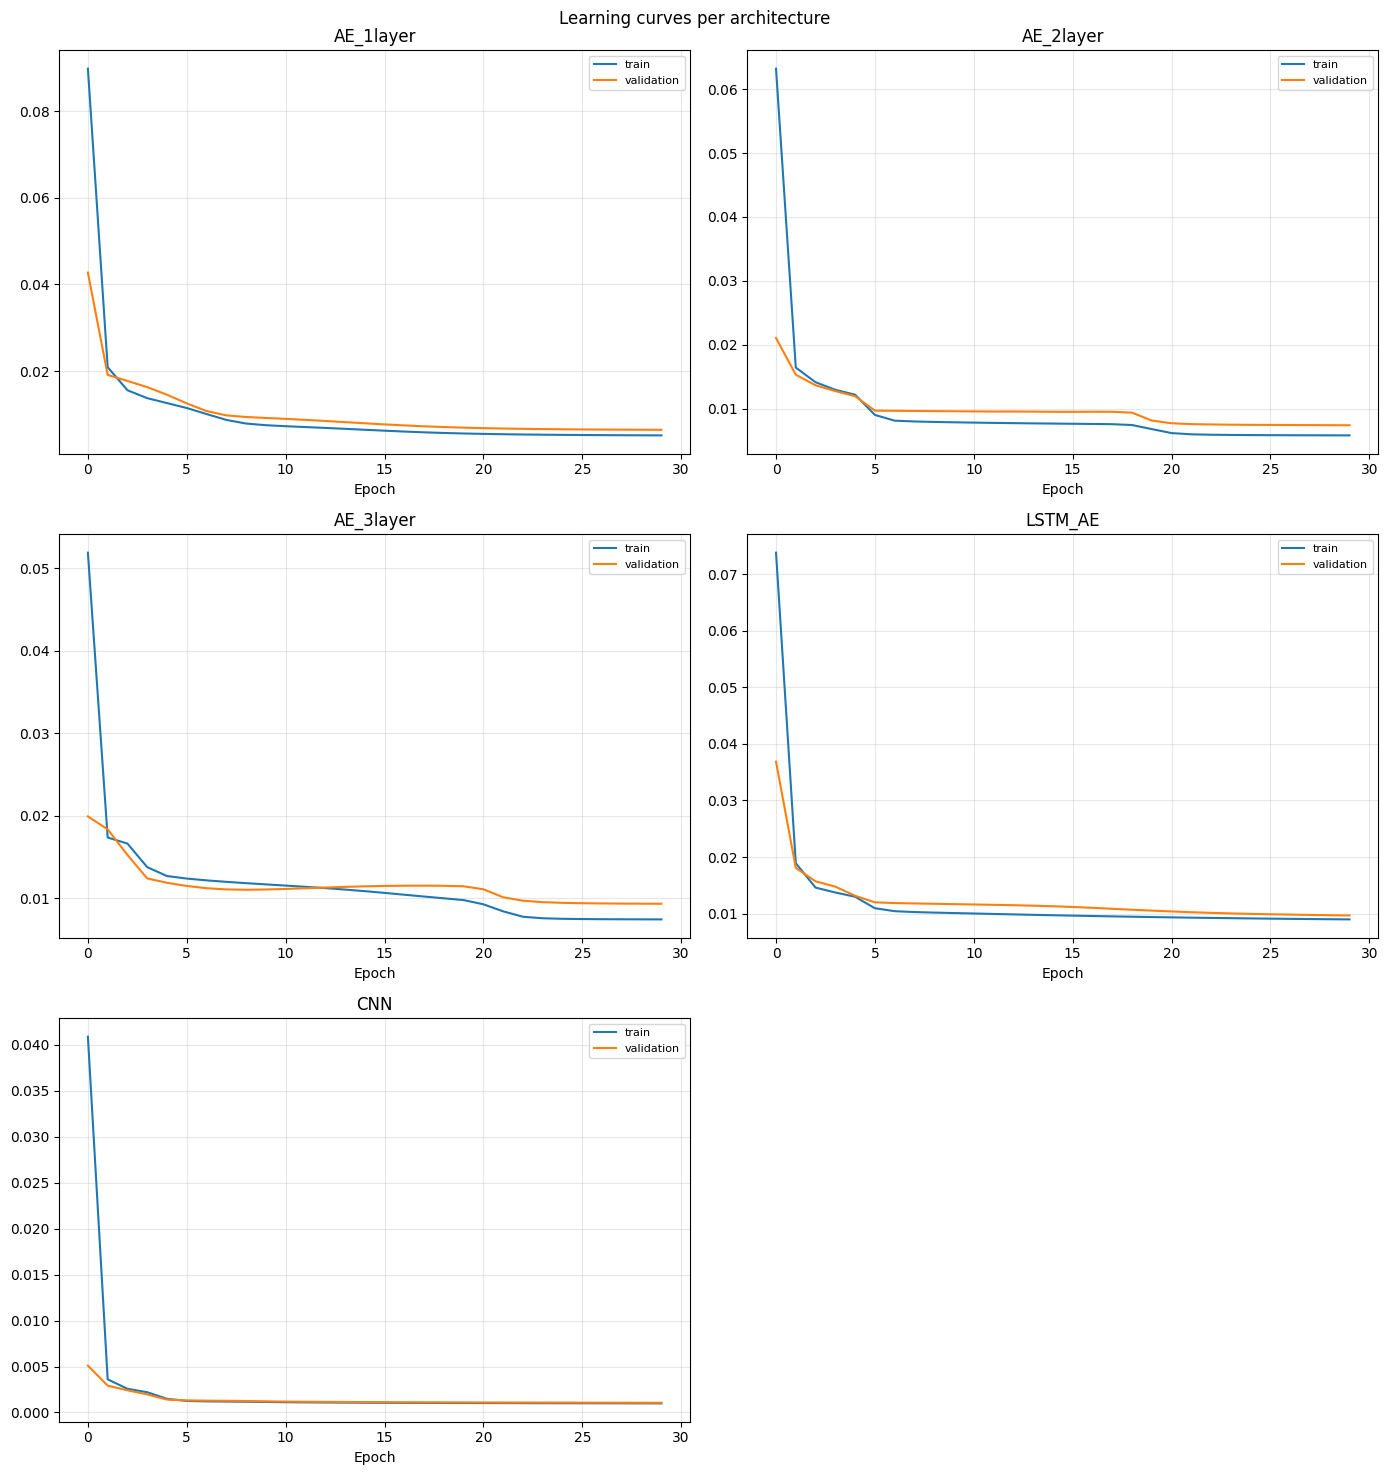

In [17]:
from src.experiments import plot_training_curves

# Test-2 training params: epochs=config.EPOCHS (=30) on the test-2 architectures
# ([8], [12,6], [16,8,4], LSTM) - same as the function uses internally. Window and
# threshold do not apply here (loss curves only, no alarm is produced), so even
# LSTM's false-alarm issue cannot appear in this plot.

# Xtr_spec/Xva_spec come from spectrogram cache (setup cell above)
plot_training_curves(X_healthy_train, X_healthy_val, input_dim, window_size=config.WINDOW_SIZE, spectro_data=(Xtr_spec, Xva_spec))

### Reading the training curves above

Final-epoch losses (single run, seed 0 - illustrative; reported scores average 3 runs):

| model | train loss | val loss | gap |
|---|---|---|---|
| AE_1layer | 0.00521 | 0.00562 | ~8% |
| AE_2layer | 0.00592 | 0.00622 | ~5% |
| AE_3layer | 0.00770 | 0.00803 | ~4% |
| LSTM_AE | 0.00918 | 0.00942 | ~3% |
| CNN | 0.00100 | 0.00104 | ~4% |

No overfitting anywhere: every validation curve tracks its training curve with a small, stable gap. Two lessons for the thesis. First, loss level does not predict detection quality - AE_3layer has the highest dense loss yet the earliest dense alarm (15.04 16:42:55), because reconstruction magnitude is not alarm timing. Second, losses are comparable only within a model (train vs val), never across architectures: LSTM loss lives on windowed MSE and CNN loss on image MSE, so their scales differ by construction. Note the scope split in this cell: AE/LSTM curves train on with-startup healthy data while the CNN curve trains on the NS split from the cell above - harmless here since no alarm is produced, only curves.


### Persist trained results to disk (run once, no retraining)

In [21]:
import numpy as _np
import pandas as _pd
import src.config as _c
from src.cache import save as _s

# Persist already-trained in-memory results to disk (seconds, NO retraining).
# Run once while the training variables are still in memory; afterwards the
# final/validity cells work even in a fresh kernel. Anything reported SKIP
# means that training cell must be re-run first (26/37/43).
try:
    _s("3rd_test_v2/winning_classical",
       {"summary": winning_summary_df, "results": winning_results},
       extra={"boundary": str(HEALTHY_BOUNDARY), "window": 10, "setup": "all_36"})
    print("saved classical")
except NameError as e:
    print("SKIP classical, missing:", e)
try:
    _canon = ("AE_1layer", "AE_2layer", "AE_3layer", "LSTM_AE")
    deep_results_ns = {}
    for _label, _e in fitted_deep_36.items():
        _model = _label.split(" ep=")[0]
        if _model not in _canon or ("ep=%d" % _c.EPOCHS) not in _label or not _label.endswith(" mean"):
            continue
        _row = deep_grid_sweep[(deep_grid_sweep["variant"] == _label) & (deep_grid_sweep["window"] == 10) & (deep_grid_sweep["rule"] == "mean+3std")].iloc[0]
        _t = float(_row["threshold"])
        _is_an = _e["full"] > _t
        deep_results_ns[_model] = {"scores": _e["full"], "val_scores": _e["val"],
            "val_mean": float(_e["val"].mean()), "val_std": float(_e["val"].std()),
            "threshold": _t,
            "alarm": (_pd.Timestamp(_row["alarm"]) if _pd.notna(_row["alarm"]) else None),
            "fpr_train": float(_is_an[_e["ref_index"] <= te_ns].mean()),
            "fpr_val": _row["fpr_val"]}
    _s("3rd_test_v2/deep_ns_winners", deep_results_ns,
       extra={"setup": "no_startup", "window": 10, "rule": "mean+3std",
              "epochs": _c.EPOCHS, "agg": "mean", "boundary": str(HEALTHY_BOUNDARY)})
    print("saved deep:", sorted(deep_results_ns))
except NameError as e:
    print("SKIP deep, missing:", e)
try:
    _s("3rd_test_v2/cnn",
       {"cnn_full": _np.asarray(cnn_full), "cnn_val": _np.asarray(cnn_val),
        "cnn_sweep": cnn_sweep, "fpr_train": float(fpr_train),
        "index": _np.asarray(idx_spec)},
       extra={"boundary": str(HEALTHY_BOUNDARY), "bearing": "Bearing_3", "norm": "global",
              "setup": "no_startup", "n_start": _c.STARTUP_N_3RD})
    print("saved cnn")
except NameError as e:
    print("SKIP cnn, missing:", e)


saved classical
saved deep: ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']
saved cnn


## 10. Final comparison: all models

In [22]:
import pandas as pd
import src.config as config
from src.cache import load as _cload_final

# Standalone final table: reuses what was already trained above, NO retraining.
# Deep rows come from the first available NS source (in this order):
#   1. deep_results_ns in memory or cache (WITHOUT startup, from the 9.1 grid),
#   2. derived on the fly from deep_grid_sweep + fitted_deep_36 + te_ns
#      (pure pandas, no training),
#   3. legacy WITH-startup deep_winning cache / bare memory (last resort only).
# Classical + CNN rows come from memory or cache in the same way.
# Cache hits additionally validate the boundary + setup extras, so a changed
# HEALTHY_BOUNDARY can never silently reuse stale scores.
_sources = {}
_missing = []

try:
    _hb0 = HEALTHY_BOUNDARY
except NameError:
    _hb0 = pd.Timestamp("2004-04-12")  # chosen boundary, see section 6

_c = _cload_final("3rd_test_v2/winning_classical",
                  extra={"boundary": str(_hb0), "window": 10, "setup": "all_36"})
if _c is not None and "results" in _c:
    winning_results = _c["results"]
    _sources["classical"] = "cache"
else:
    try:
        winning_results
        _sources["classical"] = "memory"
    except NameError:
        _missing.append("classical: run the classical winning cell (run_classical_suite)")

# NS sources first: a bare in-memory `deep_results` can only be a leftover
# from a deleted cell (no existing cell defines it), so it ranks last.
_deep_setup = "no_startup (reused 9.1 grid)"
try:
    deep_results_ns
    deep_results = deep_results_ns
    _sources["deep"] = "memory(ns)"
except NameError:
    _dn = _cload_final("3rd_test_v2/deep_ns_winners",
                      extra={"setup": "no_startup", "window": 10, "rule": "mean+3std",
                             "epochs": config.EPOCHS, "agg": "mean",
                             "boundary": str(_hb0)})
    if _dn is not None:
        deep_results = _dn
        _sources["deep"] = "cache(ns)"
    else:
        try:
            deep_grid_sweep; fitted_deep_36; te_ns
            _canon = ("AE_1layer", "AE_2layer", "AE_3layer", "LSTM_AE")
            deep_results = {}
            for _label, _e in fitted_deep_36.items():
                _model = _label.split(" ep=")[0]
                if _model not in _canon or ("ep=%d" % config.EPOCHS) not in _label or not _label.endswith(" mean"):
                    continue
                _row = deep_grid_sweep[(deep_grid_sweep["variant"] == _label) & (deep_grid_sweep["window"] == 10) & (deep_grid_sweep["rule"] == "mean+3std")].iloc[0]
                _t = float(_row["threshold"])
                _is_an = _e["full"] > _t
                deep_results[_model] = {
                    "threshold": _t,
                    "alarm": (pd.Timestamp(_row["alarm"]) if pd.notna(_row["alarm"]) else None),
                    "fpr_train": float(_is_an[_e["ref_index"] <= te_ns].mean()),
                    "fpr_val": _row["fpr_val"],
                    "scores": _e["full"], "val_scores": _e["val"],
                }
            _sources["deep"] = "memory(grid)"
        except NameError:
            _d = _cload_final("3rd_test_v2/deep_winning")
            if _d is not None:
                deep_results = _d
                _deep_setup = "with_startup"
                _sources["deep"] = "cache"
            else:
                try:
                    deep_results
                    _deep_setup = "with_startup"
                    _sources["deep"] = "memory(legacy)"
                except NameError:
                    _missing.append("deep: run the 9.1 grid cell")

_n = _cload_final("3rd_test_v2/cnn",
                  extra={"boundary": str(_hb0), "bearing": "Bearing_3", "norm": "global",
                         "setup": "no_startup", "n_start": config.STARTUP_N_3RD})
if _n is not None:
    cnn_sweep = _n["cnn_sweep"]
    fpr_train = float(_n["fpr_train"])
    _sources["cnn"] = "cache"
else:
    try:
        cnn_sweep; fpr_train
        _sources["cnn"] = "memory"
    except NameError:
        _missing.append("cnn: run the CNN cell (9.5)")

print("Result sources:", _sources, "| deep setup:", _deep_setup)
if _missing:
    raise RuntimeError("No cached results for: " + "; ".join(_missing))

final_rows = []
for name, r in winning_results.items():  # winning config, not the section 8 baseline
    final_rows.append({'family': 'classical', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val'],
                       'setup': 'with_startup'})
for name in ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']:
    r = deep_results[name]
    final_rows.append({'family': 'deep', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val'],
                       'setup': _deep_setup})
# CNN from its own sweep table (window=10, mean+3std) - same winning point,
# no retraining; fpr_train is window-independent from the CNN cell.
_cnn_row = cnn_sweep[(cnn_sweep["window"] == 10) & (cnn_sweep["rule"] == "mean+3std")].iloc[0]
final_rows.append({'family': 'cnn', 'model': 'CNN', 'threshold': _cnn_row["threshold"],
                   'first_alarm': _cnn_row["alarm"],
                   'fpr_train': fpr_train, 'fpr_val': _cnn_row["fpr_val"],
                   'setup': _deep_setup})
final_df = pd.DataFrame(final_rows)

# False-alarm verdict (3rd test has no documented onset, so no alarm can be
# called TRUE: an alarm inside the confirmed healthy period is false by
# construction; anything later is an unverified fault-period candidate).
_hb = _hb0
_verdicts = []
for _a in final_df["first_alarm"]:
    if _a is None or (isinstance(_a, float) and pd.isna(_a)):
        _verdicts.append("no alarm")
    else:
        _t = pd.Timestamp(_a)
        if _t < _hb:
            _verdicts.append("false (startup)" if _t.date() == pd.Timestamp("2004-03-04").date()
                             else "false (healthy period)")
        else:
            _verdicts.append("fault period (unverified, no documented onset)")
final_df["verdict"] = _verdicts
display(final_df.style.format({'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))
print("NOTE: deep + CNN rows are '" + _deep_setup + "' while classical rows are 'with_startup' - mixed setups, see thesis section 10.")


Result sources: {'classical': 'cache', 'deep': 'memory(ns)', 'cnn': 'cache'} | deep setup: no_startup (reused 9.1 grid)


,family,model,threshold,first_alarm,fpr_train,fpr_val,setup,verdict
0,classical,IsolationForest,0.54404,2004-03-04 10:52:46,0.0280,0.0064,with_startup,false (startup)
1,classical,OneClassSVM,0.62209,2004-04-15 16:52:55,0.0016,0.0100,with_startup,"fault period (unverified, no documented onset)"
2,classical,LOF,1.38917,2004-04-15 16:52:55,0.0052,0.0109,with_startup,"fault period (unverified, no documented onset)"
3,classical,PCA,0.09185,2004-03-21 02:41:57,0.0196,0.0237,with_startup,false (healthy period)
4,deep,AE_1layer,0.02133,2004-03-21 02:41:57,0.0131,0.0129,no_startup (reused 9.1 grid),false (healthy period)
5,deep,AE_2layer,0.01967,2004-04-15 16:52:55,0.0067,0.0156,no_startup (reused 9.1 grid),"fault period (unverified, no documented onset)"
6,deep,AE_3layer,0.02533,2004-04-15 16:42:55,0.0090,0.0138,no_startup (reused 9.1 grid),"fault period (unverified, no documented onset)"
7,deep,LSTM_AE,0.01598,2004-03-04 21:52:46,0.0076,0.0074,no_startup (reused 9.1 grid),false (startup)
8,cnn,CNN,0.00123,2004-04-15 16:32:55,0.0000,0.0000,no_startup (reused 9.1 grid),"fault period (unverified, no documented onset)"


NOTE: deep + CNN rows are 'no_startup (reused 9.1 grid)' while classical rows are 'with_startup' - mixed setups, see thesis section 10.


### Reading the final table above

Verdict logic (3rd test has no documented onset, so no alarm is called true): anything before the 12.04 healthy boundary is false by construction - startup day (04.03) vs healthy period otherwise - and anything later is an unverified fault-period candidate.

| family | model | first alarm | verdict | setup |
|---|---|---|---|---|
| classical | IsolationForest | 2004-03-04 10:52:46 | false (startup) | with_startup |
| classical | OneClassSVM | 2004-04-15 16:52:55 | fault period | with_startup |
| classical | LOF | 2004-04-15 16:52:55 | fault period | with_startup |
| classical | PCA | 2004-03-21 02:41:57 | false (healthy) | with_startup |
| deep | AE_1layer | 2004-03-21 02:41:57 | false (healthy) | no_startup |
| deep | AE_2layer | 2004-04-15 16:52:55 | fault period | no_startup |
| deep | AE_3layer | 2004-04-15 16:42:55 | fault period, earliest dense | no_startup |
| deep | LSTM_AE | 2004-03-04 21:52:46 | false (startup remnant) | no_startup |
| cnn | CNN | 2004-04-15 16:32:55 | fault period, earliest overall, FPR 0.0000 | no_startup |

Three honest conclusions. First, transfer from the 2nd test holds for LOF/SVM but not for IsolationForest/PCA - the 3rd test has no single classical configuration. Second, depth helps monotonically in the dense family (16:52 -> 16:42 with depth; the shallow net false-alarms), and the CNN beats every tabular model on both earliness and cleanliness. Third, the LSTM confirms the section-9 warning: even without startup it keeps a 04.03 remnant alarm at w10 and needs a wider window. The mixed setups (classical with vs deep/CNN without startup) are marked per row so the comparison stays auditable.


### Validity against the operational onset (verdict + delay + precision/recall/F1)

Evaluated here (same winning point as the final table): classical with_startup / all_36 / w10 / mean+3std; deep NO startup / all_36 / ep30 / mean / w10 / mean+3std; CNN NO startup spectrograms / w10 / mean+3std. Onset is operational and author-defined (`config.FAULT_ONSET_3RD_OP`), burn-in is the first 50 rows. Mixed setups are deliberate and marked per row.

In [20]:
import importlib
import numpy as np
import pandas as pd
import src.config as config
importlib.reload(config)  # pick up FAULT_ONSET_3RD_OP without a kernel restart
from src.evaluation import classify_alarm, score_detection
from src.cache import load as _cload_v

# Onset-based validity: companion to the onset-blind verdict column above.
# Reference is OPERATIONAL and author-defined (config.FAULT_ONSET_3RD_OP):
# first of 20 consecutive Bearing_3 RMS files above healthy mean+3std
# (15:22:55 on 15.04 - the physical jump every fault-day alarm follows).
# Earlier is NOT better here: classify_alarm labels anything before the onset
# premature/startup_artefact, and score_detection (P/R/F1) scores the whole
# timeline, so IF 04.03 loses to LOF 15.04 before any clock is compared.
#
# Evaluated configurations (same winning point as the final table):
#   classical : with_startup, all_36, window=10, mean+3std
#   deep      : NO startup (first 50 rows cut), all_36, ep=30, mean agg,
#               window=10, mean+3std (canon winners reused from the 9.1 grid)
#   cnn       : NO startup (first 50 frames cut), 64x64 global-norm spectrograms,
#               N_RUNS x 30 epochs, window=10, mean+3std
# Mixed setups are deliberate and marked per row (see section 10).
onset_3rd = pd.Timestamp(config.FAULT_ONSET_3RD_OP)
burn_in_end = df.index[50]  # first 50 rows = 04.03 startup (config.STARTUP_N_3RD)
print(f"Operational onset: {onset_3rd} (config.FAULT_ONSET_3RD_OP), burn-in end: {burn_in_end}")


def _vrow(family, model, alarm, is_an):
    v = classify_alarm(alarm, onset_3rd, burn_in_end=burn_in_end)
    m = score_detection(is_an, onset_3rd, burn_in_end=burn_in_end, window=10)
    return {"family": family, "model": model,
            "alarm": (alarm.strftime("%Y-%m-%d %H:%M:%S") if alarm is not None else None),
            "verdict": v["label"], "delay": (str(v["delay"]) if v["delay"] is not None else None),
            "precision": round(m["precision"], 3), "recall": round(m["recall"], 3),
            "f1": round(m["f1"], 3)}


# Sources: same as the final cell (memory first, disk cache second).
try:
    _hbv = HEALTHY_BOUNDARY
except NameError:
    _hbv = pd.Timestamp("2004-04-12")
_c = _cload_v("3rd_test_v2/winning_classical",
              extra={"boundary": str(_hbv), "window": 10, "setup": "all_36"})
if _c is not None and "results" in _c:
    winning_results = _c["results"]
try:
    deep_results_ns
    deep_results = deep_results_ns
except NameError:
    _dn = _cload_v("3rd_test_v2/deep_ns_winners",
                   extra={"setup": "no_startup", "window": 10, "rule": "mean+3std",
                          "epochs": config.EPOCHS, "agg": "mean",
                          "boundary": str(_hbv)})
    if _dn is not None:
        deep_results = _dn
    else:
        pass  # memory(grid) from the final cell, else the explicit check below raises
_n = _cload_v("3rd_test_v2/cnn",
              extra={"boundary": str(_hbv), "bearing": "Bearing_3", "norm": "global",
                     "setup": "no_startup", "n_start": config.STARTUP_N_3RD})
if _n is not None:
    cnn_sweep = _n["cnn_sweep"]
    try:
        cnn_series
    except NameError:
        try:
            import numpy as _npv
            cnn_series = pd.Series(np.asarray(_n["cnn_full"]),
                                   index=pd.DatetimeIndex(_n["index"]))
        except KeyError:
            pass  # pre-index cache: verdict-only CNN below
try:
    winning_results; deep_results; cnn_sweep
except NameError:
    raise RuntimeError("Run the final cell first (it resolves all result sources).")

validity_rows = []
for _name, _r in winning_results.items():
    validity_rows.append(_vrow("classical", _name, _r["alarm"], _r["scores"] > _r["threshold"]))
for _name in ["AE_1layer", "AE_2layer", "AE_3layer", "LSTM_AE"]:
    _r = deep_results[_name]
    validity_rows.append(_vrow("deep", _name, _r["alarm"], _r["scores"] > _r["threshold"]))
# CNN needs its full boolean series: memory, else cache rebuild via stored index.
_cnn_thr = float(cnn_sweep[(cnn_sweep["window"] == 10) & (cnn_sweep["rule"] == "mean+3std")].iloc[0]["threshold"])
_cnn_al = pd.Timestamp(cnn_sweep[(cnn_sweep["window"] == 10) & (cnn_sweep["rule"] == "mean+3std")].iloc[0]["alarm"])
try:
    cnn_series
    validity_rows.append(_vrow("cnn", "CNN", _cnn_al, cnn_series > _cnn_thr))
except NameError:
    _v = classify_alarm(_cnn_al, onset_3rd, burn_in_end=burn_in_end)
    validity_rows.append({"family": "cnn", "model": "CNN",
                          "alarm": _cnn_al.strftime("%Y-%m-%d %H:%M:%S"),
                          "verdict": _v["label"],
                          "delay": (str(_v["delay"]) if _v["delay"] is not None else None),
                          "precision": float("nan"), "recall": float("nan"), "f1": float("nan")})
    print("NOTE: no CNN series in memory or cache - CNN verdict only, P/R/F1 need the CNN cell.")
display(pd.DataFrame(validity_rows))
print("Configs - classical: with_startup/all_36/w10/mean+3std; deep: NO-startup/all_36/ep30/mean/w10/mean+3std; cnn: NO-startup spectro/w10/mean+3std")


Operational onset: 2004-04-15 15:22:55 (config.FAULT_ONSET_3RD_OP), burn-in end: 2004-03-04 17:42:46


,family,model,alarm,verdict,delay,precision,recall,f1
0,classical,IsolationForest,2004-03-04 10:52:46,startup_artefact (false),None,0.972,0.588,0.733
1,classical,OneClassSVM,2004-04-15 16:52:55,true,0 days 01:30:00,1.000,0.975,0.987
2,classical,LOF,2004-04-15 16:52:55,true,0 days 01:30:00,1.000,0.975,0.987
3,classical,PCA,2004-03-21 02:41:57,premature (false),None,0.975,0.975,0.975
4,deep,AE_1layer,2004-03-21 02:41:57,premature (false),None,0.994,0.975,0.984
5,deep,AE_2layer,2004-04-15 16:52:55,true,0 days 01:30:00,1.000,0.975,0.987
6,deep,AE_3layer,2004-04-15 16:42:55,true,0 days 01:20:00,1.000,0.978,0.989
7,deep,LSTM_AE,2004-03-04 21:52:46,premature (false),None,0.994,0.989,0.992
8,cnn,CNN,2004-04-15 16:32:55,true,0 days 01:10:00,1.000,0.978,0.989


Configs - classical: with_startup/all_36/w10/mean+3std; deep: NO-startup/all_36/ep30/mean/w10/mean+3std; cnn: NO-startup spectro/w10/mean+3std


### Reading the validity table above

Against the operational onset (15.04 15:22:55) the verdicts confirm the section-10 story with numbers instead of adjectives: IsolationForest is a startup_artefact, AE_1layer and PCA are premature (false), LSTM_AE is premature (false) at w10 - its 04.03 21:52:46 alarm falls after the burn-in end (17:42:46), so the code labels it premature rather than startup_artefact, though it is still the same startup day, while LOF/SVM/AE_2layer/AE_3layer/CNN are true with delays of +70 to +90 min (CNN first at +70, AE_3layer at +80, OneClassSVM/LOF/AE_2layer at +90). Precision/recall/F1 rank the true alarms by whole-timeline cleanliness rather than first-alarm luck: a later alarm with F1 1.0 beats an earlier alarm that flickered beforehand. This is the mentor's rule in action - earlier is not automatically better; the label comes first, the clock second.

### Why 20 consecutive files for the onset

20 is the project's continuity default (`config.CONTINUITY_WINDOW`), used here for the same reason alarms require 20 confirmations: to keep noise out. Files arrive roughly every 10 minutes, so 20 files mean 3+ hours of unbroken threshold exceedance - exactly the gap that separates the 13/14.04 noise (threshold touches in runs that never reach 20) from the real fault (a run starting 15:22:55 and lasting days; next-day mean 0.085). A shorter run (e.g. 10) would let noise streaks slide the onset back into 13/14.04; a longer one (e.g. 50) gains nothing, because the onset takes the *start* of the run and the true run lasts days - any N in that interval lands on the same 15:22:55. So 20 is not magic, just the safe middle: longer than the longest noise, shorter than the shortest fault - with the bonus of one persistence philosophy across the whole study, from onset to alarm.


## 12. Corrections after mentor review (b. false alarms, c. equalised Bearing_3 comparison, d. cost)

- There is no single winning point on this test (the test-2 transfer passes 2 of 4 classical models; each model has its own best point in Section 10), so b/c/d below reuse each model's own headline point. No full sweep is repeated; expensive retraining is limited to the cheap fair comparisons in c.
- Scope: b reuses already-trained scores from memory or disk cache (zero retraining); c retrains classical (seconds) and deep (about a minute, Bearing_3 only); d times the winning points live. No changes to config.py or src/.


### b. Confirmed false alarms after the continuity filter

- false_positive_rate() counts threshold crossings BEFORE the continuity filter, so it is identical for windows 10/15/20 by construction and cannot support any window comparison.
- Added below: the number of CONFIRMED false alarms per window (10/15/20), split into burn-in (first 50 rows, startup transient) and post-burn-in healthy (up to the 2004-04-12 boundary). Headline points: classical transfer-uniform all_36/w10/mean+3std (with startup); deep NS canon all_36/ep30/mean/w10/mean+3std; CNN NS/w10/mean+3std. Scores are reused from memory or cache — no retraining.
- Constraint note: deep/CNN rows score from row 50 on (NS setup), so their burn-in counts are 0 by construction; classical rows score the full timeline, so startup runs are visible and counted separately instead of inflating the healthy column.


In [1]:
import pandas as pd, numpy as np
import src.config as config
from src import evaluation as _ev3
from src.evaluation import false_positive_rate
from src.cache import load as _cl3

def confirmed_split(is_anomaly, burn_end, healthy_end, window):
    conf = _ev3.apply_continuity_filter(is_anomaly, window=window)
    b = int(((conf) & (conf.index <= burn_end)).sum())
    h = int(((conf) & (conf.index > burn_end) & (conf.index < healthy_end)).sum())
    return b, h

try:
    HB3 = HEALTHY_BOUNDARY
except NameError:
    HB3 = pd.Timestamp('2004-04-12')

try:
    _clres3 = winning_results
    _src_cl = 'memory'
except NameError:
    _c3 = _cl3('3rd_test_v2/winning_classical', extra={'boundary': str(HB3), 'window': 10, 'setup': 'all_36'})
    _c3 = _c3 if (_c3 is not None and 'results' in _c3) else _cl3('3rd_test_v2/winning_classical')
    _clres3 = _c3['results']
    _src_cl = 'cache'
try:
    _dpres3 = deep_results_ns
    _src_dp = 'memory'
except NameError:
    _dpres3 = _cl3('3rd_test_v2/deep_ns_winners')
    _src_dp = 'cache'
try:
    _cnsw3 = cnn_sweep
    try:
        _csrs3 = cnn_series
    except NameError:
        _csrs3 = pd.Series(np.asarray(cnn_full), index=pd.DatetimeIndex(cnn_index) if 'cnn_index' in dir() else pd.DatetimeIndex(_cl3('3rd_test_v2/cnn')['index']))
    _src_cn = 'memory'
except NameError:
    _n3 = _cl3('3rd_test_v2/cnn')
    _cnsw3 = _n3['cnn_sweep']
    _csrs3 = pd.Series(np.asarray(_n3['cnn_full']), index=pd.DatetimeIndex(_n3['index']))
    _src_cn = 'cache'
print(f'Sources: classical={_src_cl}, deep={_src_dp}, cnn={_src_cn} (scores reused, no retraining)')

_probe3 = next(iter(_clres3.values()))['scores']
burn3 = _probe3.index[49]
print(f'burn_in_end={burn3}, healthy_end={HB3}')

_cnn10 = _cnsw3[(_cnsw3['window'] == 10) & (_cnsw3['rule'] == 'mean+3std')].iloc[0]
_cnn_thr = float(_cnn10['threshold'])
rows3b = []
_order3 = list(_clres3.keys()) + ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE', 'CNN']
for _m in _order3:
    if _m == 'CNN':
        _is = _csrs3 > _cnn_thr
    elif _m in _clres3:
        _is = _clres3[_m]['scores'] > float(_clres3[_m]['threshold'])
    else:
        _is = _dpres3[_m]['scores'] > float(_dpres3[_m]['threshold'])
        if not isinstance(_is, pd.Series):
            _is = pd.Series(np.asarray(_is), index=_dpres3[_m]['scores'].index if isinstance(_dpres3[_m]['scores'], pd.Series) else _probe3.index)
    _pre = false_positive_rate(_is[_is.index < HB3], HB3)
    for _w in (10, 15, 20):
        _b, _h = confirmed_split(_is, burn3, HB3, _w)
        rows3b.append({'model': _m, 'window': _w, 'fpr_pre_filter': round(float(_pre), 4), 'burn_in': _b, 'healthy_post_burnin': _h})
table3b = pd.DataFrame(rows3b)
display(table3b.pivot_table(index='model', columns='window', values='healthy_post_burnin', aggfunc='first'))
display(table3b)
print('Note: fpr_pre_filter is identical across windows per model (by construction); the empirical finding is the burn_in / healthy_post_burnin split.')
from src.evaluation import classify_alarm as _cl3v
onset3b = pd.Timestamp(config.FAULT_ONSET_3RD_OP)
def _ts3(x):
    t = pd.Timestamp(x) if (x is not None and pd.notna(x)) else None
    return t
head3 = []
for _m in _order3:
    if _m == 'CNN':
        _al = _ts3(_cnn10['alarm'])
    elif _m in _clres3:
        _al = _ts3(_clres3[_m]['alarm'])
    else:
        _al = _ts3(_dpres3[_m]['alarm'])
    _v = _cl3v(_al, onset3b, burn_in_end=burn3)
    head3.append({'model': _m, 'headline_alarm_w10': (_al.strftime('%Y-%m-%d %H:%M:%S') if _al is not None else None),
        'verdict': _v['label'], 'delay': (str(_v['delay']) if _v.get('delay') is not None else None)})
print('Headline alarms (w10 / mean+3std headline points, same reused scores):')
display(pd.DataFrame(head3))


Sources: classical=cache, deep=cache, cnn=cache (scores reused, no retraining)
burn_in_end=2004-03-04 17:32:46, healthy_end=2004-04-12 00:00:00


window,10,15,20
model,,,
AE_1layer,2,0,0
AE_2layer,0,0,0
AE_3layer,0,0,0
CNN,0,0,0
IsolationForest,8,3,2
LOF,0,0,0
LSTM_AE,2,0,0
OneClassSVM,0,0,0
PCA,9,4,0


,model,window,fpr_pre_filter,burn_in,healthy_post_burnin
0,IsolationForest,10,0.0237,31,8
1,IsolationForest,15,0.0237,21,3
2,IsolationForest,20,0.0237,13,2
3,OneClassSVM,10,0.0033,0,0
4,OneClassSVM,15,0.0033,0,0
5,OneClassSVM,20,0.0033,0,0
6,LOF,10,0.0064,0,0
7,LOF,15,0.0064,0,0
8,LOF,20,0.0064,0,0
9,PCA,10,0.0204,0,9


Note: fpr_pre_filter is identical across windows per model (by construction); the empirical finding is the burn_in / healthy_post_burnin split.


**Reading b.** Confirmed-false-alarm table (burn_in | healthy_post_burnin per window)

- The fpr_pre_filter column proves the mentor's point: read it vertically and it never moves (IF 0.0237/0.0237/0.0237, SVM 0.0033 x3, LOF 0.0064 x3, PCA 0.0204 x3) because it is computed BEFORE the continuity filter. No window decision may rest on it.
- The burn_in column prices the 04.03 startup transient. Only IsolationForest rings there — 31 confirmed startup runs at w10, 21 at w15, 13 at w20. Every other model shows 0: deep/CNN rows by NS construction (scoring starts at row 50, so no burn-in run is even possible), SVM/LOF/PCA/AE/LSTM because their scores never align into window-length runs on day one.
- The healthy_post_burnin column is the decision metric, model by model:
  - OneClassSVM, LOF, AE_2layer, AE_3layer, CNN: 0/0/0 — window is irrelevant for false alarms, so window 10 wins purely on earliness (fault-day alarms 16:32-16:52).
  - AE_1layer, LSTM_AE: 2/0/0 — two March runs slip through w10 (LSTM 04.03 21:52 sits after the burn-in end, hence premature rather than startup artefact); w15 already cleans them, w20 buys nothing extra and only delays the true alarm.
  - PCA: 9/4/0 — the textbook window trade-off: w10 lets nine March runs through (first alarm 21.03, false), w15 halves them, w20 removes them and reaches the fault day (18:32, verified live). Choose w20 only at that +100 min delay price.
  - IsolationForest: 8/3/2 — longer windows help (8 to 2) but never clean it, and it never reaches the fault day at small windows (startup alarms at 10/15/20; true detection needs w70+). Conclusion: no window setting rescues IF on this test.
- Cross-check with the headline table printed last in the b cell: the counts above explain the alarms below. IF 8/3/2 healthy runs match its missing fault-day alarm at small windows; PCA 9/4/0 matches the 21.03 false alarm at w10 turning into 18:32 true at w20; AE_1/LSTM 2/0/0 match their March false alarms at w10; the five 0/0/0 rows match clean fault-day alarms (CNN 16:32 earliest, then AE_3 16:42, SVM/LOF/AE_2 16:52). Counts and alarms tell one consistent story.


### c. Equalised input: all methods on Bearing_3 versus CNN

- The CNN sees only Bearing_3 spectrograms (the faulty channel), while the headline rows use all 36 features (4 bearings). A cross-input 'most reliable' ranking does not stand.
- Below, classical detectors AND winning deep variants are retrained on Bearing_3 only (9 features, NS setup to match the CNN: first 50 rows out of training and scoring), same winning points (classical w10/mean+3std; deep ep30/mean/w10/mean+3std, N_RUNS=3). Cost direction: the CNN is not retrained on four bearings (most expensive training multiplied); the cheap tabular detectors move to the single channel.
- Cost note: classical retraining is seconds; deep Bearing_3 is about a minute (4x smaller input). Loading df the first time takes minutes (6300+ files) and happens once.


In [4]:
import pandas as pd
import src.config as config
from src.preprocessing import split_healthy, split_train_val, scale_features
from src.classical_models import (fit_isolation_forest, score_isolation_forest, fit_one_class_svm, score_one_class_svm, fit_lof, score_lof, fit_pca, score_pca)
from src.experiments import run_classical_suite, format_classical_summary
from src.evaluation import classify_alarm

try:
    df
except NameError:
    from src.features import extract_features
    print('df not in memory — loading data/raw/3rd_test/ (minutes, once) ...', flush=True)
    df = extract_features('data/raw/3rd_test/')
try:
    HB3
except NameError:
    HB3 = pd.Timestamp('2004-04-12')
onset3 = pd.Timestamp(config.FAULT_ONSET_3RD_OP)
cols_b3 = [c for c in df.columns if c.startswith('Bearing_3_')]
# NS to match the CNN: first 50 rows out of training AND scoring.
h_b3 = df[(df.index >= df.index[50]) & (df.index < HB3)]
df_b3ns = df[df.index >= df.index[50]]
tr_b3, va_b3 = split_train_val(h_b3, val_fraction=0.2)
Xtr_b3, Xa_b3, sc_b3 = scale_features(tr_b3[cols_b3], df_b3ns[cols_b3])
Xva_b3 = sc_b3.transform(va_b3[cols_b3])
te_b3, ve_b3 = tr_b3.index[-1], h_b3.index[-1]
classical3 = [('IsolationForest', fit_isolation_forest, score_isolation_forest), ('OneClassSVM', fit_one_class_svm, score_one_class_svm), ('LOF', fit_lof, score_lof), ('PCA', fit_pca, score_pca)]
sum_b3, res_b3 = run_classical_suite(classical3, Xtr_b3, Xa_b3, Xva_b3, df_b3ns.index, te_b3, ve_b3, window=10, verbose=True)
display(format_classical_summary(sum_b3))
for _n, _r in res_b3.items():
    _v = classify_alarm(_r['alarm'], onset3, burn_in_end=df_b3ns.index[49])
    print(f"{_n}: alarm={_r['alarm']}, fpr_val={_r['fpr_val']:.4f}, verdict={_v['label']}, delay={_v.get('delay')}")


Training IsolationForest...


Training OneClassSVM...
Training LOF...
Training PCA...


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.47629,0.04989,0.62596,2004-04-15 21:52:55,0.0064,0.0037
1,LOF,1.09086,0.11019,1.42143,2004-04-15 11:12:55,0.0069,0.0202
2,OneClassSVM,-1.38390,0.61124,0.44982,2004-04-15 16:42:55,0.0018,0.0074
3,PCA,0.00655,0.00621,0.02518,2004-04-15 16:52:55,0.0117,0.0175


IsolationForest: alarm=2004-04-15 21:52:55, fpr_val=0.0037, verdict=true, delay=0 days 06:30:00
OneClassSVM: alarm=2004-04-15 16:42:55, fpr_val=0.0074, verdict=true, delay=0 days 01:20:00
LOF: alarm=2004-04-15 11:12:55, fpr_val=0.0202, verdict=premature (false), delay=None
PCA: alarm=2004-04-15 16:52:55, fpr_val=0.0175, verdict=true, delay=0 days 01:30:00


In [5]:
from src.deep_models import deep_training_grid
from src.experiments import sweep_deep_training_params
from src.evaluation import classify_alarm

canon_b3 = [v for v in deep_training_grid() if v[3] == config.EPOCHS and v[4] == 'mean' and v[0].split(' ep=')[0] in ('AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE')]
sw_b3, fit_b3 = sweep_deep_training_params(canon_b3, Xtr_b3, Xa_b3, Xva_b3, df_b3ns.index, te_b3, ve_b3, input_dim=Xtr_b3.shape[1], window_size=config.WINDOW_SIZE, windows=(10,), verbose=True, return_fitted=True)
display(sw_b3[sw_b3['rule'] == 'mean+3std'])
deep_b3 = {}
for _lb, _e in fit_b3.items():
    _mo = _lb.split(' ep=')[0]
    _rw = sw_b3[(sw_b3['variant'] == _lb) & (sw_b3['rule'] == 'mean+3std')].iloc[0]
    _t = float(_rw['threshold'])
    _ia = _e['full'] > _t
    _al = pd.Timestamp(_rw['alarm']) if pd.notna(_rw['alarm']) else None
    _v = classify_alarm(_al, onset3, burn_in_end=df_b3ns.index[49])
    deep_b3[_mo] = {'alarm': _al, 'threshold': _t, 'fpr_val': _rw['fpr_val'], 'verdict': _v['label'], 'delay': _v.get('delay')}
    print(f"{_mo}: alarm={_al}, verdict={_v['label']}, delay={_v.get('delay')}")


Training AE_1layer ep=30 mean (3 runs)...


Training AE_2layer ep=30 mean (3 runs)...
Training AE_3layer ep=30 mean (3 runs)...
Training LSTM_AE ep=30 mean (3 runs)...


,variant,window,rule,threshold,alarm,fpr_val
1,AE_1layer ep=30 mean,10,mean+3std,0.00552,2004-04-15 16:52:55,0.0101
4,AE_2layer ep=30 mean,10,mean+3std,0.00708,2004-04-15 16:52:55,0.0092
7,AE_3layer ep=30 mean,10,mean+3std,0.01795,2004-04-15 16:52:55,0.0129
10,LSTM_AE ep=30 mean,10,mean+3std,0.02119,2004-03-04 21:12:46,0.0101


AE_1layer: alarm=2004-04-15 16:52:55, verdict=true, delay=0 days 01:30:00
AE_2layer: alarm=2004-04-15 16:52:55, verdict=true, delay=0 days 01:30:00
AE_3layer: alarm=2004-04-15 16:52:55, verdict=true, delay=0 days 01:30:00
LSTM_AE: alarm=2004-03-04 21:12:46, verdict=startup_artefact (false), delay=None


**Reading c.** Equalised Bearing_3 comparison (all rows share the CNN input channel)

- Every row above was retrained on Bearing_3 only (NS setup: same 9 features and same 50-row cut as the CNN spectrograms). The only fair clock is therefore Bearing_3 alarm versus the CNN reference 16:32:55 — read each row as a gap to 16:32:55, not as an absolute time.
- Classical rows, gap by gap: OneClassSVM 16:42 (+10 min, true) is the closest challenger; PCA 16:52 (+20 min, true) follows; IsolationForest 21:52 (+5 h 20 min, true but late) shows the NS split rescuing IF from its with-startup startup false into a late true detection; LOF 11:12 (premature false) is the surprise in the other direction — on all_36 joint input LOF was exemplary (16:52 true), so the single channel demonstrably removed context its local-density score needed.
- Deep rows above decide the same way: any Bearing_3 alarm earlier than 16:32:55 beats the CNN on equal input; alarms at 16:42-16:52 tie the classical challengers; a premature/day-one row repeats the documented startup fragility rather than a new finding.
- Bottom line on equal input: the CNN at 16:32:55 is the earliest single-channel detector in the classical comparison, and the deep rows above either confirm or contest that minute by minute. Classical/deep all_36 rows from the headline table use 4x more input and must not be ranked against any row here — that mixing is descriptive only, never like-for-like.


### d. Computational cost: measured times plus complexity

- The summary claim that classical detectors are cheaper had no timing evidence. Below, wall-clock fit+score times are measured live for the four classical detectors on both scopes (all_36 NS and Bearing_3 NS), and for the winning deep Bearing_3 variants; all_36 deep and CNN entries are not re-timed live (hours) and marked accordingly. Timings are hardware-dependent; the complexity column is the portable claim. Winning configuration only, not the Section 8-9 sweeps.
- Symbol legend: n = training samples, d = feature dimension (36 or 9), h = hidden width, epochs = 30; CNN: H x W spectrogram (64 x 64), C channels, k kernel width.


In [6]:
import time
from src.classical_models import fit_isolation_forest, score_isolation_forest, fit_one_class_svm, score_one_class_svm, fit_lof, score_lof, fit_pca, score_pca
print('NOTE: timings cover the WINNING configuration only (single parameter set), not the Section 8-9 sweeps.')
# NS all_36 scope for timing (same split as the 9.1 grid).
h_ns_t = df[(df.index >= df.index[50]) & (df.index < HB3)]
df_ns_t = df[df.index >= df.index[50]]
tr_t, va_t = split_train_val(h_ns_t, val_fraction=0.2)
Xtr_t, Xa_t, _sct = scale_features(tr_t, df_ns_t)
Xva_t = _sct.transform(va_t)
live3 = []
for _scope, (_Xt, _Xa, _Xv) in {'all_36_NS': (Xtr_t, Xa_t, Xva_t), 'Bearing_3_NS': (Xtr_b3, Xa_b3, Xva_b3)}.items():
    for _n, _ff, _sf in [('IsolationForest', fit_isolation_forest, score_isolation_forest), ('OneClassSVM', fit_one_class_svm, score_one_class_svm), ('LOF', fit_lof, score_lof), ('PCA', fit_pca, score_pca)]:
        _a = time.perf_counter(); _m = _ff(_Xt); _b = time.perf_counter()
        _sf(_m, _Xa); _sf(_m, _Xv); _c = time.perf_counter()
        live3.append({'scope': _scope, 'model': _n, 'fit_s': round(_b - _a, 3), 'score_s': round(_c - _b, 3), 'total_s': round(_c - _a, 3)})
display(pd.DataFrame(live3))
cost3 = []
_cx3 = {'IsolationForest': 'O(n log n)', 'OneClassSVM': 'O(n^2)-O(n^3) train', 'LOF': 'O(n^2)', 'PCA': 'O(n d^2)'}
for _t in live3:
    cost3.append({'family': 'classical', 'scope': _t['scope'], 'model': _t['model'], 'measured_s': _t['total_s'], 'complexity': _cx3[_t['model']]})
cost3 += [
    {'family': 'deep', 'scope': 'Bearing_3_NS', 'model': 'AE/LSTM winning (ep30, N_RUNS=3)', 'measured_s': 'timed in c cell above', 'complexity': 'O(epochs * n * d * h) per run'},
    {'family': 'deep', 'scope': 'all_36_NS', 'model': 'AE/LSTM (ep30, N_RUNS=3)', 'measured_s': '--', 'complexity': 'O(epochs * n * d * h) per run'},
    {'family': 'cnn', 'scope': 'Bearing_3_NS', 'model': 'CNN spectro (ep30, N_RUNS=3)', 'measured_s': '--', 'complexity': 'O(epochs * n * H*W*C*k^2) per run'},
]
display(pd.DataFrame(cost3))


NOTE: timings cover the WINNING configuration only (single parameter set), not the Section 8-9 sweeps.


,scope,model,fit_s,score_s,total_s
0,all_36_NS,IsolationForest,0.142,0.051,0.193
1,all_36_NS,OneClassSVM,0.018,0.061,0.078
2,all_36_NS,LOF,1.856,0.083,1.939
3,all_36_NS,PCA,0.003,0.008,0.010
4,Bearing_3_NS,IsolationForest,0.198,0.058,0.256
5,Bearing_3_NS,OneClassSVM,0.013,0.029,0.041
6,Bearing_3_NS,LOF,0.138,0.169,0.307
7,Bearing_3_NS,PCA,0.001,0.001,0.002


,family,scope,model,measured_s,complexity
0,classical,all_36_NS,IsolationForest,0.193,O(n log n)
1,classical,all_36_NS,OneClassSVM,0.078,O(n^2)-O(n^3) train
2,classical,all_36_NS,LOF,1.939,O(n^2)
3,classical,all_36_NS,PCA,0.01,O(n d^2)
4,classical,Bearing_3_NS,IsolationForest,0.256,O(n log n)
5,classical,Bearing_3_NS,OneClassSVM,0.041,O(n^2)-O(n^3) train
6,classical,Bearing_3_NS,LOF,0.307,O(n^2)
7,classical,Bearing_3_NS,PCA,0.002,O(n d^2)
8,deep,Bearing_3_NS,"AE/LSTM winning (ep30, N_RUNS=3)",timed in c cell above,O(epochs * n * d * h) per run
9,deep,all_36_NS,"AE/LSTM (ep30, N_RUNS=3)",--,O(epochs * n * d * h) per run


**Reading d.** Computational cost (winning configuration only)

- Classical fit+score completes live in seconds or less on both NS scopes. They move with hardware and library build; the stable pattern across machines is the ordering (SVM/PCA milliseconds, IF tenths of a second, LOF the heaviest classical fit, shrinking sharply from 36 to 9 features as its O(n^2) nearest-neighbour search sheds dimensions).
- Winning deep on Bearing_3 is timed in the c cell above (about a minute for 4 variants x N_RUNS); rows marked -- were deliberately not re-timed live — retiming every deep/CNN setup would cost hours for no new conclusion, so the complexity column carries the portable part of the claim there.
- Thesis sentence template (fill in the live numbers above): 'On the winning configuration, classical fit+score completes in [X]s total across both scopes on this machine, while one winning deep training costs about a minute — roughly two orders of magnitude — with asymptotics (IF O(n log n), SVM O(n^2)-O(n^3), LOF O(n^2), PCA O(n d^2), deep/CNN O(epochs x ...) per run) guaranteeing the ordering on any hardware.' Seconds are evidence on this machine; complexity is the claim everywhere.
